Name : Aarya Malghe
PRN : 202301100061
Batch : PEC4

“The dataset used is the Energy Efficiency dataset, where Cooling Load is predicted based on eight building-related features such as surface area, wall area, and glazing properties.”

“The objective of this project is to build a neural network model to accurately predict Cooling Load using various optimization techniques.”

In [4]:
from google.colab import files
uploaded = files.upload()

Saving ENB2012_data 4.xlsx to ENB2012_data 4.xlsx


In [5]:
import pandas as pd

df = pd.read_excel("ENB2012_data 4.xlsx")
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [6]:
# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Check shape
print("\nShape of dataset:")
print(df.shape)

First 5 rows:
     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28

Shape of dataset:
(768, 10)


In [7]:
print("Column Names:")
print(df.columns)

Column Names:
Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')


In [8]:
print(df.dtypes)

X1    float64
X2    float64
X3    float64
X4    float64
X5    float64
X6      int64
X7    float64
X8      int64
Y1    float64
Y2    float64
dtype: object


In [9]:
# --- Rename columns from X1-X8, Y1-Y2 to descriptive feature names ---
df.columns = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Overall_Height",
    "Orientation",
    "Glazing_Area",
    "Glazing_Area_Distribution",
    "Heating_Load",
    "Cooling_Load"
]

print(df.columns)

Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height', 'Orientation', 'Glazing_Area',
       'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load'],
      dtype='object')


In [10]:
# Verify no missing values exist in the dataset
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64


In [11]:
print(df.shape)
print(df.isnull().sum())
print(df.describe())

(768, 10)
Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64
       Relative_Compactness  Surface_Area   Wall_Area   Roof_Area  \
count            768.000000    768.000000  768.000000  768.000000   
mean               0.764167    671.708333  318.500000  176.604167   
std                0.105777     88.086116   43.626481   45.165950   
min                0.620000    514.500000  245.000000  110.250000   
25%                0.682500    606.375000  294.000000  140.875000   
50%                0.750000    673.750000  318.500000  183.750000   
75%                0.830000    741.125000  343.000000  220.500000   
max                0.980000    808.500000  416.500000  220.500000   

       Overall_Height  Orientation  Glazing_A

In [12]:
# Check for duplicate rows
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [13]:
# Split dataset: X = 8 input features, y = Cooling Load (target)
X = df.drop(columns=["Heating_Load", "Cooling_Load"])
y = df["Cooling_Load"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (768, 8)
Shape of y: (768,)


In [14]:
# Shuffle and split data: 80% train, 20% test
import numpy as np

# Convert to numpy arrays
X_np = X.values
y_np = y.values

# Set random seed
np.random.seed(42)

# Shuffle indices
indices = np.arange(X_np.shape[0])
np.random.shuffle(indices)

# Compute split index
split_index = int(0.8 * X_np.shape[0])

# Split
train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train = X_np[train_indices]
X_test = X_np[test_indices]

y_train = y_np[train_indices].reshape(-1, 1)
y_test = y_np[test_indices].reshape(-1, 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614, 1)
y_test shape: (154, 1)


In [15]:
# Compute mean and std from training data
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# Standardize
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

print("Mean of scaled train:")
print(X_train_scaled.mean(axis=0))

print("\nStd of scaled train:")
print(X_train_scaled.std(axis=0))

Mean of scaled train:
[-6.46496971e-15  4.47343935e-16 -6.41180919e-16  8.15489551e-17
  5.06290630e-17  4.05032504e-17 -3.84780879e-16  3.33428544e-16]

Std of scaled train:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [16]:
# Reshape target to column vector
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print("New y_train shape:", y_train.shape)
print("New y_test shape:", y_test.shape)

New y_train shape: (614, 1)
New y_test shape: (154, 1)


In [17]:
# Define network architecture: 8 inputs, 5 hidden neurons, 1 output
import numpy as np

input_size = 8
hidden_size = 5
output_size = 1

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)


W1 shape: (8, 5)
W2 shape: (5, 1)


In [18]:
# Sigmoid activation
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Forward pass on training data
Z1 = np.dot(X_train_scaled, W1) + b1
A1 = sigmoid(Z1)

Z2 = np.dot(A1, W2) + b2
y_pred = Z2   # Linear output (regression)

print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)
print("y_pred shape:", y_pred.shape)

Z1 shape: (614, 5)
A1 shape: (614, 5)
y_pred shape: (614, 1)


In [19]:
# Mean Squared Error
loss = np.mean((y_train - y_pred) ** 2)

print("Initial Loss:", loss)

Initial Loss: 712.9134421133562


In [20]:
# Number of training samples
n = y_train.shape[0]

# Gradient at output layer
dZ2 = (y_pred - y_train) / n

print("dZ2 shape:", dZ2.shape)

dZ2 shape: (614, 1)


In [21]:
# Gradients for W2 and b2
dW2 = np.dot(A1.T, dZ2)
db2 = np.sum(dZ2, axis=0, keepdims=True)

print("dW2 shape:", dW2.shape)
print("db2 shape:", db2.shape)

dW2 shape: (5, 1)
db2 shape: (1, 1)


In [22]:
# Backprop to hidden layer
dA1 = np.dot(dZ2, W2.T)

dZ1 = dA1 * (A1 * (1 - A1))

print("dZ1 shape:", dZ1.shape)

dZ1 shape: (614, 5)


In [23]:
# Gradients for first layer
dW1 = np.dot(X_train_scaled.T, dZ1)
db1 = np.sum(dZ1, axis=0, keepdims=True)

print("dW1 shape:", dW1.shape)
print("db1 shape:", db1.shape)

dW1 shape: (8, 5)
db1 shape: (1, 5)


In [24]:
learning_rate = 0.01

# Update output layer
W2 -= learning_rate * dW2
b2 -= learning_rate * db2

# Update hidden layer
W1 -= learning_rate * dW1
b1 -= learning_rate * db1

print("Weights updated successfully.")

Weights updated successfully.


In [25]:
# Forward pass again after weight update
Z1_new = np.dot(X_train_scaled, W1) + b1
A1_new = 1 / (1 + np.exp(-Z1_new))

Z2_new = np.dot(A1_new, W2) + b2
y_pred_new = Z2_new

# Compute new loss
new_loss = np.mean((y_train - y_pred_new) ** 2)

print("Old Loss:", loss)
print("New Loss:", new_loss)

Old Loss: 712.9134421133562
New Loss: 685.1801879553099


In [26]:
# Reinitialize weights (important for clean training)
np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

learning_rate = 0.1
epochs = 100

loss_history = []

for epoch in range(epochs):

    # Forward pass
    Z1 = np.dot(X_train_scaled, W1) + b1
    A1 = 1 / (1 + np.exp(-Z1))

    Z2 = np.dot(A1, W2) + b2
    y_pred = Z2

    # Loss
    loss = np.mean((y_train - y_pred) ** 2)
    loss_history.append(loss)

    # Backprop
    n = y_train.shape[0]
    dZ2 = (y_pred - y_train) / n
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * (A1 * (1 - A1))
    dW1 = np.dot(X_train_scaled.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")
        print(f"  W1 (8→5):\n{W1.round(4)}")
        print(f"  W2 (5→1):\n{W2.round(4)}")
        print()

print("Final Loss:", loss_history[-1])

Epoch 0, Loss: 712.9134
  W1 (8→5):
[[ 0.0607 -0.0112  0.063   0.1478 -0.0461]
 [-0.0352  0.1552  0.0786 -0.0422  0.0783]
 [-0.039  -0.0449  0.0231 -0.1941 -0.1868]
 [-0.0713 -0.1048  0.0338 -0.0848 -0.1108]
 [ 0.1622 -0.0189  0.0043 -0.1488 -0.0861]
 [ 0.0113 -0.1151  0.0375 -0.0602 -0.0296]
 [-0.0559  0.1862 -0.002  -0.1075  0.0738]
 [-0.1211  0.0211 -0.1961 -0.1331  0.0182]]
  W2 (5→1):
[[1.3647]
 [1.2572]
 [1.2272]
 [1.2086]
 [1.0909]]

Epoch 10, Loss: 16.4028
  W1 (8→5):
[[ 0.3463  0.334   0.4227  0.4711  0.3225]
 [-0.3808 -0.2499 -0.3402 -0.4392 -0.3571]
 [ 0.5297  0.5206  0.5849  0.4744  0.435 ]
 [-0.6837 -0.774  -0.6471 -0.7957 -0.8367]
 [ 0.867   0.7455  0.7782  0.6621  0.7319]
 [ 0.0244 -0.0399  0.0414 -0.0141  0.0049]
 [ 0.2472  0.3887  0.2868  0.2073  0.3179]
 [-0.0132  0.0615 -0.0598 -0.0233  0.0597]]
  W2 (5→1):
[[5.3628]
 [5.1522]
 [5.0876]
 [5.0155]
 [4.8082]]

Epoch 20, Loss: 15.7878
  W1 (8→5):
[[ 0.3355  0.2503  0.3947  0.4739  0.2848]
 [-0.4047 -0.203  -0.3468 -0.47

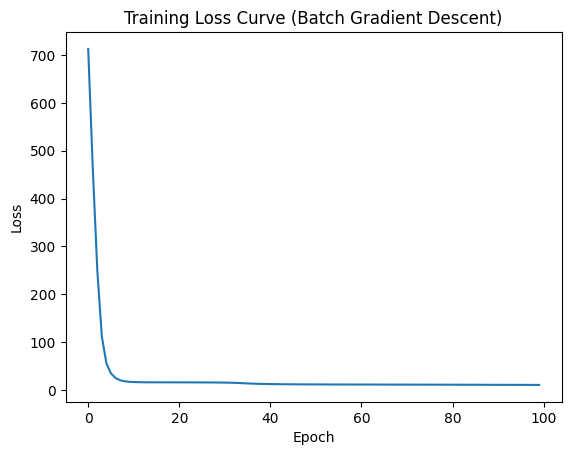

In [27]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve (Batch Gradient Descent)")
plt.show()

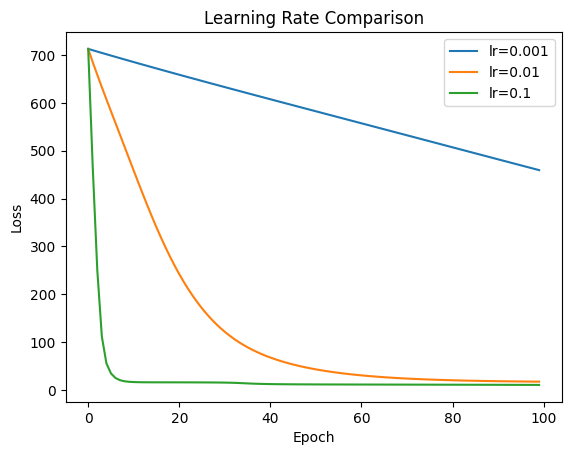

In [28]:
# --- Compare effect of different fixed learning rates (0.001, 0.01, 0.1)
def train_model(lr):

    np.random.seed(42)
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.1
    b2 = np.zeros((1, output_size))

    epochs = 100
    loss_history = []

    for epoch in range(epochs):

        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-Z1))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    return loss_history


loss_lr_001 = train_model(0.001)
loss_lr_01 = train_model(0.01)
loss_lr_1 = train_model(0.1)

import matplotlib.pyplot as plt

plt.plot(loss_lr_001, label="lr=0.001")
plt.plot(loss_lr_01, label="lr=0.01")
plt.plot(loss_lr_1, label="lr=0.1")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

In [29]:
# Study effect of hidden layer size (1,2,3,5,10 neurons) on train and test loss
def train_with_hidden_size(hidden_size, lr=0.1, epochs=100):

    np.random.seed(42)

    # Initialize weights
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    for epoch in range(epochs):

        # Forward
        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-Z1))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    # Final training loss
    train_loss = np.mean((y_train - y_pred) ** 2)

    # Test loss
    Z1_test = np.dot(X_test_scaled, W1) + b1
    A1_test = 1 / (1 + np.exp(-Z1_test))
    Z2_test = np.dot(A1_test, W2) + b2
    y_test_pred = Z2_test

    test_loss = np.mean((y_test - y_test_pred) ** 2)

    return train_loss, test_loss


hidden_sizes = [1, 2, 3, 5, 10]

for h in hidden_sizes:
    train_loss, test_loss = train_with_hidden_size(h)
    print(f"Hidden neurons: {h} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

Hidden neurons: 1 | Train Loss: 16.7903 | Test Loss: 17.8073
Hidden neurons: 2 | Train Loss: 15.7785 | Test Loss: 16.7838
Hidden neurons: 3 | Train Loss: 13.9359 | Test Loss: 13.1883
Hidden neurons: 5 | Train Loss: 10.4132 | Test Loss: 10.5961
Hidden neurons: 10 | Train Loss: 9.7717 | Test Loss: 9.5783


In [30]:
# --- Batch Training: use entire dataset at once, update weights once per epoch ---
def train_batch(hidden_size=10, lr=0.1, epochs=100):

    np.random.seed(42)

    # Initialize weights
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Forward
        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-Z1))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")
            print(f"  W1 (8→10):\n{W1.round(4)}")
            print(f"  W2 (10→1):\n{W2.round(4)}")
            print()

    return loss_history, W1, b1, W2, b2

batch_loss = train_batch()

Epoch 0, Loss: 708.0997
  W1 (8→10):
[[ 4.630e-02 -8.400e-03  8.740e-02  1.452e-01 -3.560e-02 -3.100e-02
   1.714e-01  8.150e-02 -5.490e-02  6.200e-02]
 [-4.280e-02 -5.230e-02  2.000e-04 -1.836e-01 -1.596e-01 -4.820e-02
  -1.157e-01  2.630e-02 -8.230e-02 -1.494e-01]
 [ 1.445e-01 -1.910e-02  2.140e-02 -1.475e-01 -6.200e-02  6.100e-03
  -1.063e-01  4.070e-02 -6.530e-02 -2.420e-02]
 [-5.570e-02  1.779e-01 -3.190e-02 -9.580e-02  9.860e-02 -1.118e-01
   2.500e-03 -2.025e-01 -1.219e-01  9.300e-03]
 [ 6.920e-02  2.480e-02  2.020e-02 -4.080e-02 -1.648e-01 -8.270e-02
  -2.670e-02  1.126e-01  2.300e-02 -1.655e-01]
 [ 3.240e-02 -3.840e-02 -6.730e-02  6.110e-02  1.028e-01  9.300e-02
  -8.360e-02 -3.080e-02  3.300e-02  9.780e-02]
 [-4.920e-02 -1.650e-02 -1.022e-01 -1.225e-01  7.660e-02  1.328e-01
  -2.100e-03  1.020e-01  3.320e-02 -6.160e-02]
 [ 3.590e-02  1.542e-01 -2.100e-03  1.561e-01 -2.624e-01  8.170e-02
   9.600e-03 -2.960e-02  8.700e-03 -1.983e-01]]
  W2 (10→1):
[[1.2742]
 [1.2456]
 [1.3865]

In [31]:
# SGD Training: iterate through all 614 samples one by one, updating weights after each
def train_sgd(hidden_size=10, lr=0.1, epochs=100):

    np.random.seed(42)

    # Initialize weights
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        for i in range(X_train_scaled.shape[0]):

            x_i = X_train_scaled[i:i+1]
            y_i = y_train[i:i+1]

            # Forward
            Z1 = np.dot(x_i, W1) + b1
            A1 = 1 / (1 + np.exp(-Z1))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            dZ2 = (y_pred - y_i)
            dW2 = np.dot(A1.T, dZ2)
            db2 = dZ2

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(x_i.T, dZ1)
            db1 = dZ1

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Compute full training loss after epoch
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-Z1_full))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")
            print(f"  W1 (8→10):\n{W1.round(4)}")
            print(f"  W2 (10→1):\n{W2.round(4)}")
            print()

    return loss_history, W1, b1, W2, b2

In [32]:
sgd_loss = train_sgd()

Epoch 0, Loss: 12.0990
  W1 (8→10):
[[ 1.2706e+00 -5.3757e+00 -2.7582e+00 -1.0303e+00  1.3340e+00  1.2129e+00
   1.6780e+00  1.4085e+00  1.3102e+00 -4.9810e-01]
 [-1.2251e+00  5.3231e+00  2.7768e+00  1.1434e+00 -1.4976e+00 -1.2895e+00
  -1.3575e+00 -1.0872e+00 -1.4035e+00  4.6830e-01]
 [ 1.9189e+00  3.0396e+00  4.5034e+00  6.2797e+00  1.7638e+00  1.7725e+00
   2.1124e+00  2.1403e+00  2.0921e+00  4.4770e-01]
 [-2.0686e+00  3.9752e+00  5.3300e-01 -1.8880e+00 -2.0917e+00 -2.1786e+00
  -2.2825e+00 -2.3044e+00 -2.4553e+00  3.8770e-01]
 [ 1.8496e+00 -3.7167e+00 -2.4780e-01  9.3280e-01  1.7017e+00  1.7314e+00
   1.9056e+00  1.9077e+00  2.1460e+00 -1.0127e+00]
 [-3.0630e-01 -5.1000e-03  1.3800e+00 -7.9120e-01 -2.2670e-01 -4.9500e-02
  -1.1100e-02  8.3100e-02  4.5570e-01 -1.4630e-01]
 [ 5.3590e-01  1.8334e+00 -2.0780e-01  2.0357e+00  6.2380e-01  5.2620e-01
   4.2240e-01  4.6960e-01  4.3650e-01  4.1223e+00]
 [-5.7380e-01 -5.6830e-01 -1.7650e-01  1.8371e+00 -6.0930e-01 -8.9670e-01
  -5.2360e-01 -

In [33]:
# Mini-Batch Training: shuffle data each epoch, update weights after every 32 samples
def train_minibatch(hidden_size=10, lr=0.1, epochs=100, batch_size=32):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Shuffle data every epoch
        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Forward
            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-Z1))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Full training loss after epoch
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-Z1_full))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")
            print(f"  W1 (8→10):\n{W1.round(4)}")
            print(f"  W2 (10→1):\n{W2.round(4)}")
            print()

    return loss_history, W1, b1, W2, b2


mini_loss = train_minibatch()

Epoch 0, Loss: 13.5235
  W1 (8→10):
[[ 0.1371 -0.1684  0.2817  0.3272 -0.1449 -0.2817  0.3633  0.211  -0.0028
   0.2414]
 [-0.2747 -0.0532 -0.3314 -0.4994 -0.2096  0.0365 -0.4456 -0.2427 -0.281
  -0.4692]
 [ 0.5561  0.5618  0.4441  0.3426  0.5339  0.5886  0.3708  0.4348  0.4128
   0.4581]
 [-0.4811 -0.1025 -0.5603 -0.6411 -0.2373 -0.3091 -0.5505 -0.6559 -0.5468
  -0.5363]
 [ 0.6965  0.536   0.729   0.6817  0.3957  0.364   0.7015  0.7585  0.649
   0.5624]
 [-0.0083 -0.0452 -0.1001  0.0083  0.1036  0.0829 -0.1123 -0.0683 -0.0082
   0.0346]
 [ 0.2227  0.3943  0.1273  0.1195  0.4409  0.5288  0.1984  0.2928  0.3147
   0.1805]
 [ 0.0322  0.2275 -0.0398  0.1377 -0.1616  0.1708 -0.0107 -0.0525  0.0424
  -0.158 ]]
  W2 (10→1):
[[3.2219]
 [2.9986]
 [3.3365]
 [3.0784]
 [2.8098]
 [3.0383]
 [3.2491]
 [3.3876]
 [3.0842]
 [3.0957]]

Epoch 10, Loss: 9.9409
  W1 (8→10):
[[ 3.3240e-01 -5.2470e-01  5.4400e-01  5.1940e-01 -5.6690e-01 -1.0225e+00
   5.6260e-01  4.5930e-01 -3.7780e-01  4.9870e-01]
 [-6.8940

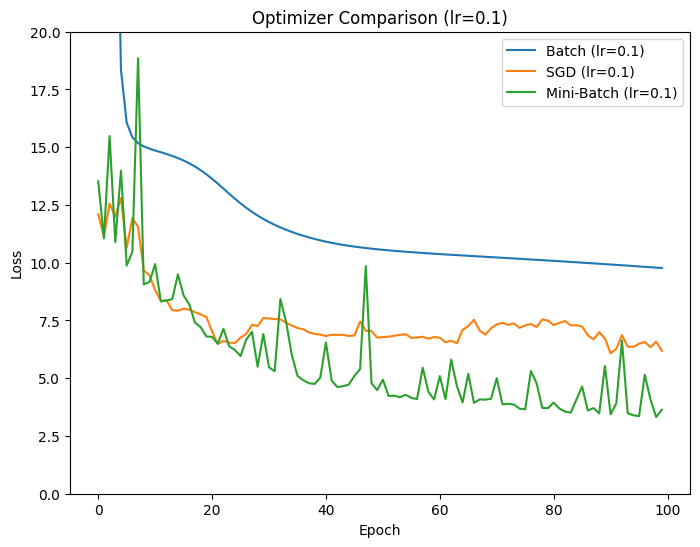

In [34]:
# Optimizer Comparison
plt.figure(figsize=(8,6))

plt.plot(batch_loss[0], label="Batch (lr=0.1)")
plt.plot(sgd_loss[0], label="SGD (lr=0.1)")
plt.plot(mini_loss[0], label="Mini-Batch (lr=0.1)")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison (lr=0.1)")
plt.legend()
plt.ylim(0, 20)   # tighter zoom
plt.show()

In [35]:
#Mini-Batch + Classical Momentum

def train_momentum(hidden_size=10, lr=0.05, epochs=100, batch_size=32, beta=0.9):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    # Initialize velocity
    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Forward
            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-Z1))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Momentum update
            vW2 = beta * vW2 - lr * dW2
            vb2 = beta * vb2 - lr * db2
            vW1 = beta * vW1 - lr * dW1
            vb1 = beta * vb1 - lr * db1

            W2 += vW2
            b2 += vb2
            W1 += vW1
            b1 += vb1

        # Compute full loss
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-Z1_full))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


momentum_loss = train_momentum()

Epoch 0, Loss: 50.72759909408899
Epoch 10, Loss: 5.788163514030661
Epoch 20, Loss: 4.828418164782124
Epoch 30, Loss: 5.6352140148228065
Epoch 40, Loss: 4.547461233385554
Epoch 50, Loss: 4.790143707839199
Epoch 60, Loss: 4.415674529917225
Epoch 70, Loss: 4.044166255571124
Epoch 80, Loss: 3.515860939540154
Epoch 90, Loss: 3.520411454403526


In [36]:
# Batch + Classical Momentum
def train_batch_momentum(hidden_size=10, lr=0.05, epochs=100, beta=0.9):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        # Forward (FULL DATA)
        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-Z1))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Momentum update
        vW2 = beta * vW2 - lr * dW2
        vb2 = beta * vb2 - lr * db2
        vW1 = beta * vW1 - lr * dW1
        vb1 = beta * vb1 - lr * db1

        W2 += vW2
        b2 += vb2
        W1 += vW1
        b1 += vb1

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


batch_momentum_loss = train_batch_momentum()

Epoch 0, Loss: 708.0997366334449
Epoch 10, Loss: 96.41500981698645
Epoch 20, Loss: 34.14247510646676
Epoch 30, Loss: 17.66557743260617
Epoch 40, Loss: 16.918820623965317
Epoch 50, Loss: 11.458449042684984
Epoch 60, Loss: 10.583508744648597
Epoch 70, Loss: 9.909377898046243
Epoch 80, Loss: 9.267404169267982
Epoch 90, Loss: 8.934386180166923


In [37]:
# SGD + Classical Momentum
def train_sgd_momentum(hidden_size=10, lr=0.01, epochs=100, beta=0.9):

    np.random.seed(42)

    # Initialize weights
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    # Initialize velocity
    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        for i in range(X_train_scaled.shape[0]):

            x_i = X_train_scaled[i:i+1]
            y_i = y_train[i:i+1]

            # Forward pass
            Z1 = np.dot(x_i, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))  # stable sigmoid
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backpropagation
            dZ2 = (y_pred - y_i)
            dW2 = np.dot(A1.T, dZ2)
            db2 = dZ2

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(x_i.T, dZ1)
            db1 = dZ1

            # Momentum update
            vW2 = beta * vW2 - lr * dW2
            vb2 = beta * vb2 - lr * db2
            vW1 = beta * vW1 - lr * dW1
            vb1 = beta * vb1 - lr * db1

            # Apply update
            W2 += vW2
            b2 += vb2
            W1 += vW1
            b1 += vb1

        # Compute full loss after each epoch
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


sgd_momentum_loss = train_sgd_momentum()

Epoch 0, Loss: 16.72738882662387
Epoch 10, Loss: 6.9781384315343375
Epoch 20, Loss: 7.6753140019363295
Epoch 30, Loss: 9.01613797480114
Epoch 40, Loss: 6.4868221325706035
Epoch 50, Loss: 6.455495983525209
Epoch 60, Loss: 6.815135042606719
Epoch 70, Loss: 6.532801511571781
Epoch 80, Loss: 6.371082999200242
Epoch 90, Loss: 6.073161427234402


In [38]:
# Batch + Nesterov Momentum
def train_batch_nesterov(hidden_size=10, lr=0.05, epochs=100, beta=0.9):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        # Lookahead weights
        W1_look = W1 + beta * vW1
        b1_look = b1 + beta * vb1
        W2_look = W2 + beta * vW2
        b2_look = b2 + beta * vb2

        # Forward pass
        Z1 = np.dot(X_train_scaled, W1_look) + b1_look
        A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
        Z2 = np.dot(A1, W2_look) + b2_look
        y_pred = Z2

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2_look.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Velocity update
        vW2 = beta * vW2 - lr * dW2
        vb2 = beta * vb2 - lr * db2
        vW1 = beta * vW1 - lr * dW1
        vb1 = beta * vb1 - lr * db1

        # Weight update
        W2 += vW2
        b2 += vb2
        W1 += vW1
        b1 += vb1

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
batch_nesterov_loss = train_batch_nesterov()

Epoch 0, Loss: 708.0997366334449
Epoch 10, Loss: 19.88602071094728
Epoch 20, Loss: 11.346727472171645
Epoch 30, Loss: 10.725336388778375
Epoch 40, Loss: 10.28879538129658
Epoch 50, Loss: 9.765833460334518
Epoch 60, Loss: 9.497562841694968
Epoch 70, Loss: 9.266718953276634
Epoch 80, Loss: 9.069565342996894
Epoch 90, Loss: 8.868183497910765


In [39]:
# Mini Batch + Nesterov Momentum

def train_minibatch_nesterov(hidden_size=10, lr=0.05, epochs=100, batch_size=32, beta=0.9):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Lookahead
            W1_look = W1 + beta * vW1
            b1_look = b1 + beta * vb1
            W2_look = W2 + beta * vW2
            b2_look = b2 + beta * vb2

            Z1 = np.dot(X_batch, W1_look) + b1_look
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2_look) + b2_look
            y_pred = Z2

            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2_look.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            vW2 = beta * vW2 - lr * dW2
            vb2 = beta * vb2 - lr * db2
            vW1 = beta * vW1 - lr * dW1
            vb1 = beta * vb1 - lr * db1

            W2 += vW2
            b2 += vb2
            W1 += vW1
            b1 += vb1

        # Full loss
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2

mini_nesterov_loss = train_minibatch_nesterov()

Epoch 0, Loss: 13.388603322503865
Epoch 10, Loss: 7.293591553380626
Epoch 20, Loss: 5.889785526308059
Epoch 30, Loss: 5.295067730293643
Epoch 40, Loss: 4.882342163709579
Epoch 50, Loss: 5.12576746534903
Epoch 60, Loss: 4.488212737167021
Epoch 70, Loss: 4.486250622470585
Epoch 80, Loss: 3.6027148956988153
Epoch 90, Loss: 3.2933125487713837


In [40]:
# SGD + Nesterov Momentum

def train_sgd_nesterov(hidden_size=10, lr=0.01, epochs=100, beta=0.9):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        for i in range(X_train_scaled.shape[0]):

            x_i = X_train_scaled[i:i+1]
            y_i = y_train[i:i+1]

            W1_look = W1 + beta * vW1
            b1_look = b1 + beta * vb1
            W2_look = W2 + beta * vW2
            b2_look = b2 + beta * vb2

            Z1 = np.dot(x_i, W1_look) + b1_look
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2_look) + b2_look
            y_pred = Z2

            dZ2 = (y_pred - y_i)
            dW2 = np.dot(A1.T, dZ2)
            db2 = dZ2

            dA1 = np.dot(dZ2, W2_look.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(x_i.T, dZ1)
            db1 = dZ1

            vW2 = beta * vW2 - lr * dW2
            vb2 = beta * vb2 - lr * db2
            vW1 = beta * vW1 - lr * dW1
            vb1 = beta * vb1 - lr * db1

            W2 += vW2
            b2 += vb2
            W1 += vW1
            b1 += vb1

        # Full loss
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2

sgd_nesterov_loss = train_sgd_nesterov()

Epoch 0, Loss: 13.303941004681304
Epoch 10, Loss: 9.639347819480001
Epoch 20, Loss: 9.094328529987648
Epoch 30, Loss: 9.182950424681387
Epoch 40, Loss: 9.806523454379697
Epoch 50, Loss: 7.367842141626396
Epoch 60, Loss: 4.832363076462237
Epoch 70, Loss: 4.803425194177097
Epoch 80, Loss: 4.806562225855355
Epoch 90, Loss: 4.654825626132198


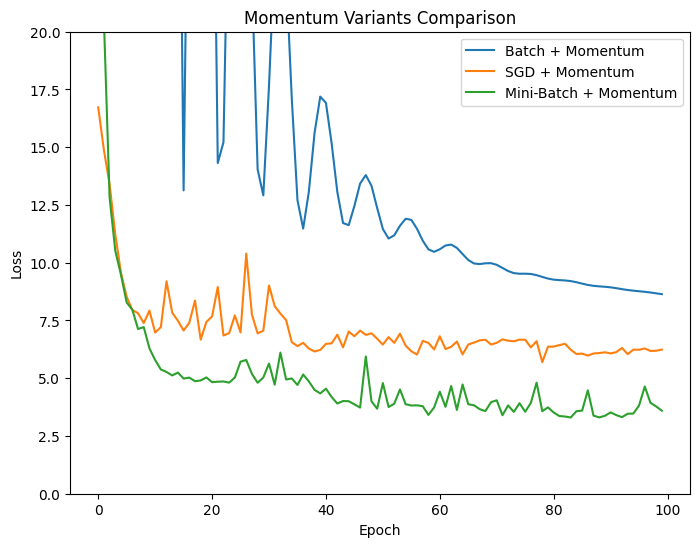

In [41]:
plt.figure(figsize=(8,6))

plt.plot(batch_momentum_loss[0], label="Batch + Momentum")
plt.plot(sgd_momentum_loss[0], label="SGD + Momentum")
plt.plot(momentum_loss[0], label="Mini-Batch + Momentum")

plt.title("Momentum Variants Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 20)
plt.show()

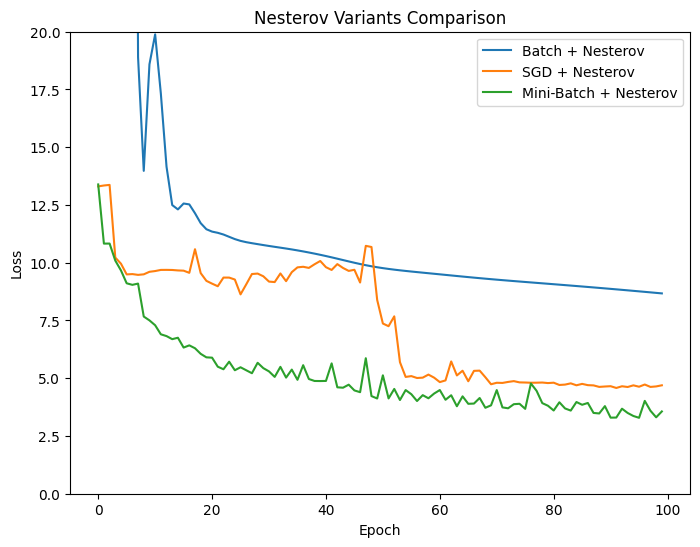

In [42]:
plt.figure(figsize=(8,6))

plt.plot(batch_nesterov_loss[0], label="Batch + Nesterov")
plt.plot(sgd_nesterov_loss[0], label="SGD + Nesterov")
plt.plot(mini_nesterov_loss[0], label="Mini-Batch + Nesterov")

plt.title("Nesterov Variants Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 20)
plt.show()

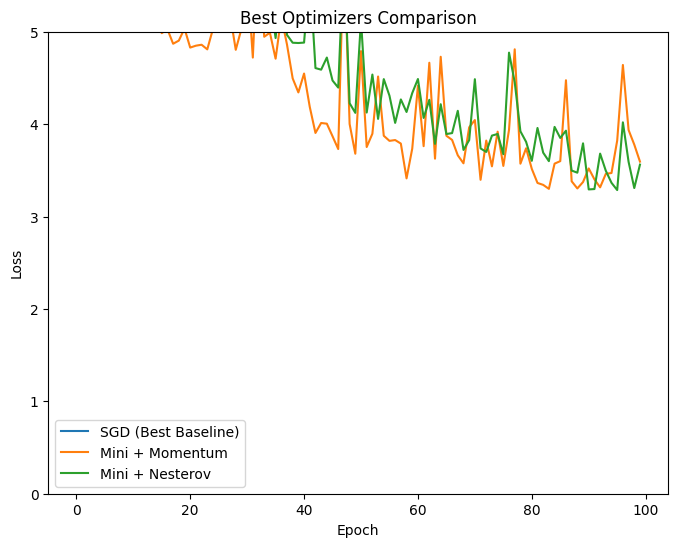

In [43]:
plt.figure(figsize=(8,6))

plt.plot(sgd_loss[0], label="SGD (Best Baseline)")
plt.plot(momentum_loss[0], label="Mini + Momentum")
plt.plot(mini_nesterov_loss[0], label="Mini + Nesterov")

plt.title("Best Optimizers Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 5)
plt.show()

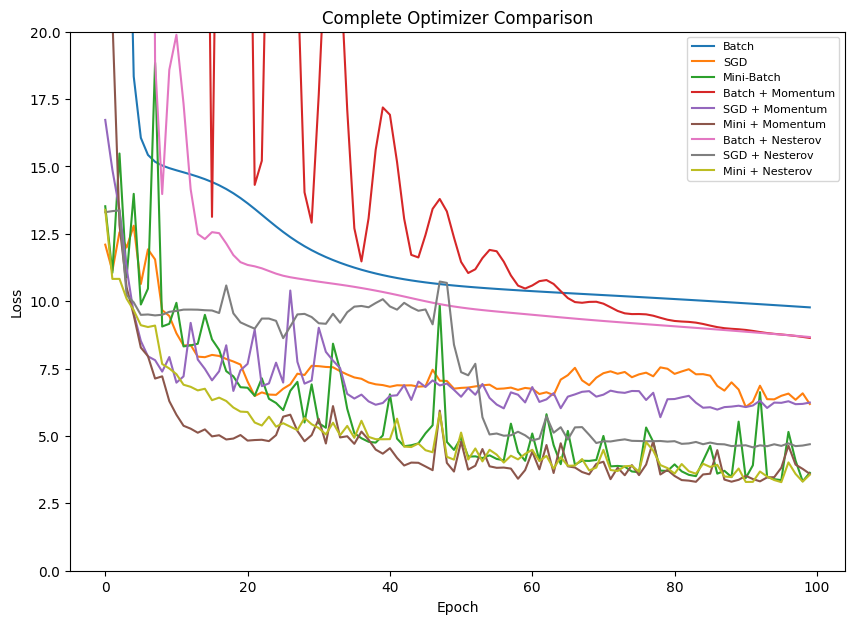

In [44]:
plt.figure(figsize=(10,7))

# Baseline
plt.plot(batch_loss[0], label="Batch")
plt.plot(sgd_loss[0], label="SGD")
plt.plot(mini_loss[0], label="Mini-Batch")

# Momentum
plt.plot(batch_momentum_loss[0], label="Batch + Momentum")
plt.plot(sgd_momentum_loss[0], label="SGD + Momentum")
plt.plot(momentum_loss[0], label="Mini + Momentum")

# Nesterov
plt.plot(batch_nesterov_loss[0], label="Batch + Nesterov")
plt.plot(sgd_nesterov_loss[0], label="SGD + Nesterov")
plt.plot(mini_nesterov_loss[0], label="Mini + Nesterov")

plt.title("Complete Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right", fontsize=8)
plt.ylim(0, 20)
plt.show()

In [45]:


# Batch Gradient Descent with Time-Based Learning Rate Decay

def train_batch_time_decay(hidden_size=10, initial_lr=0.1, decay_rate=0.01, epochs=100):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Time-based learning rate
        lr = initial_lr / (1 + decay_rate * epoch)

        # Forward
        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.4f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
batch_time_loss = train_batch_time_decay()

Epoch 0, LR: 0.1000, Loss: 708.0997366334449
Epoch 10, LR: 0.0909, Loss: 14.891115861229956
Epoch 20, LR: 0.0833, Loss: 13.943610437752309
Epoch 30, LR: 0.0769, Loss: 12.305354458041933
Epoch 40, LR: 0.0714, Loss: 11.350172190929028
Epoch 50, LR: 0.0667, Loss: 10.875722006058211
Epoch 60, LR: 0.0625, Loss: 10.631197148959242
Epoch 70, LR: 0.0588, Loss: 10.489387144807038
Epoch 80, LR: 0.0556, Loss: 10.389474700718774
Epoch 90, LR: 0.0526, Loss: 10.307276629849937


In [46]:
# SGD with Time-Based Learning Rate Decay
# Learning rate decreases over epochs to allow smoother convergence

def train_sgd_time_decay(hidden_size=10, initial_lr=0.01, decay_rate=0.01, epochs=100):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Time-based learning rate
        lr = initial_lr / (1 + decay_rate * epoch)

        for i in range(X_train_scaled.shape[0]):

            x_i = X_train_scaled[i:i+1]
            y_i = y_train[i:i+1]

            # Forward
            Z1 = np.dot(x_i, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            dZ2 = (y_pred - y_i)
            dW2 = np.dot(A1.T, dZ2)
            db2 = dZ2

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(x_i.T, dZ1)
            db1 = dZ1

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Full loss after epoch
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")


    return loss_history, W1, b1, W2, b2
sgd_time_loss, W1_sgd, b1_sgd, W2_sgd, b2_sgd = train_sgd_time_decay()

Epoch 0, LR: 0.01000, Loss: 11.669174066939247
Epoch 10, LR: 0.00909, Loss: 5.264134678987944
Epoch 20, LR: 0.00833, Loss: 3.922766529695401
Epoch 30, LR: 0.00769, Loss: 3.5030024298246456
Epoch 40, LR: 0.00714, Loss: 3.075189734222919
Epoch 50, LR: 0.00667, Loss: 2.862472038070363
Epoch 60, LR: 0.00625, Loss: 2.754544822935766
Epoch 70, LR: 0.00588, Loss: 2.7009607868815393
Epoch 80, LR: 0.00556, Loss: 2.6710425418933563
Epoch 90, LR: 0.00526, Loss: 2.6508948526440403


In [47]:
# Mini-Batch Gradient Descent with Time-Based Learning Rate Decay
# Learning rate decreases gradually over epochs

def train_minibatch_time_decay(hidden_size=10, initial_lr=0.05, decay_rate=0.01,
                                epochs=100, batch_size=32):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Time-based learning rate
        lr = initial_lr / (1 + decay_rate * epoch)

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Forward
            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Compute full loss after epoch
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
mini_time_loss = train_minibatch_time_decay()

Epoch 0, LR: 0.05000, Loss: 15.334743278546357
Epoch 10, LR: 0.04545, Loss: 10.236757945310377
Epoch 20, LR: 0.04167, Loss: 8.537607846268346
Epoch 30, LR: 0.03846, Loss: 7.810682281215419
Epoch 40, LR: 0.03571, Loss: 7.501926078560758
Epoch 50, LR: 0.03333, Loss: 6.3494837001587765
Epoch 60, LR: 0.03125, Loss: 6.036739926115856
Epoch 70, LR: 0.02941, Loss: 5.429137633093248
Epoch 80, LR: 0.02778, Loss: 4.926321434215562
Epoch 90, LR: 0.02632, Loss: 4.672536194536016


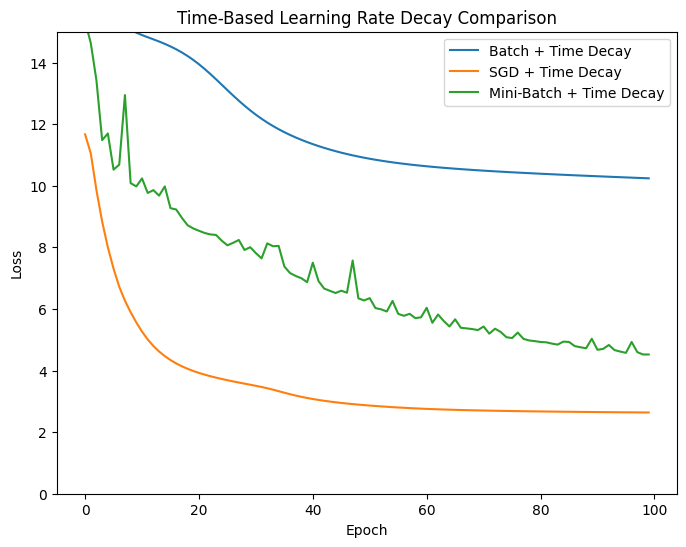

In [48]:
plt.figure(figsize=(8,6))

plt.plot(batch_time_loss[0], label="Batch + Time Decay")
plt.plot(sgd_time_loss, label="SGD + Time Decay")
plt.plot(mini_time_loss[0], label="Mini-Batch + Time Decay")

plt.title("Time-Based Learning Rate Decay Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 15)
plt.show()

In [49]:
# Batch Gradient Descent with Step Decay
# Learning rate drops by a fixed factor every 'step_size' epochs

def train_batch_step_decay(hidden_size=10, initial_lr=0.1, drop=0.5,
                           step_size=20, epochs=100):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Step decay formula
        lr = initial_lr * (drop ** (epoch // step_size))

        # Forward
        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
batch_step_loss = train_batch_step_decay()

Epoch 0, LR: 0.10000, Loss: 708.0997366334449
Epoch 10, LR: 0.10000, Loss: 14.85798900545975
Epoch 20, LR: 0.05000, Loss: 13.633264874822263
Epoch 30, LR: 0.05000, Loss: 12.56884849669455
Epoch 40, LR: 0.02500, Loss: 11.763009409882148
Epoch 50, LR: 0.02500, Loss: 11.479738220703975
Epoch 60, LR: 0.01250, Loss: 11.250778901191872
Epoch 70, LR: 0.01250, Loss: 11.153286628659401
Epoch 80, LR: 0.00625, Loss: 11.065657732124942
Epoch 90, LR: 0.00625, Loss: 11.025356297574868


In [50]:
# Mini-Batch Gradient Descent with Step Decay
# Learning rate drops by a fixed factor every 'step_size' epochs

def train_minibatch_step_decay(hidden_size=10, initial_lr=0.05, drop=0.5,
                               step_size=20, epochs=100, batch_size=32):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Step decay formula
        lr = initial_lr * (drop ** (epoch // step_size))

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Forward
            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Full loss
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
mini_step_loss = train_minibatch_step_decay()

Epoch 0, LR: 0.05000, Loss: 15.334743278546357
Epoch 10, LR: 0.05000, Loss: 10.288687914839866
Epoch 20, LR: 0.02500, Loss: 8.312502122517463
Epoch 30, LR: 0.02500, Loss: 7.856150663530916
Epoch 40, LR: 0.01250, Loss: 7.408078548884368
Epoch 50, LR: 0.01250, Loss: 7.024460654181244
Epoch 60, LR: 0.00625, Loss: 6.71247528668719
Epoch 70, LR: 0.00625, Loss: 6.556791105976816
Epoch 80, LR: 0.00313, Loss: 6.426929611603069
Epoch 90, LR: 0.00313, Loss: 6.3618917418681855


In [51]:
# SGD with Step Learning Rate Decay
# Learning rate drops by a fixed factor every 'step_size' epochs

def train_sgd_step_decay(hidden_size=10, initial_lr=0.01, drop=0.5,
                         step_size=20, epochs=100):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Step decay formula
        lr = initial_lr * (drop ** (epoch // step_size))

        for i in range(X_train_scaled.shape[0]):

            x_i = X_train_scaled[i:i+1]
            y_i = y_train[i:i+1]

            # Forward
            Z1 = np.dot(x_i, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            dZ2 = (y_pred - y_i)
            dW2 = np.dot(A1.T, dZ2)
            db2 = dZ2

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(x_i.T, dZ1)
            db1 = dZ1

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Full loss after epoch
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
sgd_step_loss = train_sgd_step_decay()

Epoch 0, LR: 0.01000, Loss: 11.669174066939247
Epoch 10, LR: 0.01000, Loss: 5.170727038526047
Epoch 20, LR: 0.00500, Loss: 3.811806186058389
Epoch 30, LR: 0.00500, Loss: 3.552126358583911
Epoch 40, LR: 0.00250, Loss: 3.2946457138188645
Epoch 50, LR: 0.00250, Loss: 3.1333975332756148
Epoch 60, LR: 0.00125, Loss: 2.9957324772465674
Epoch 70, LR: 0.00125, Loss: 2.9415842599844972
Epoch 80, LR: 0.00063, Loss: 2.893536640882158
Epoch 90, LR: 0.00063, Loss: 2.870890868394624


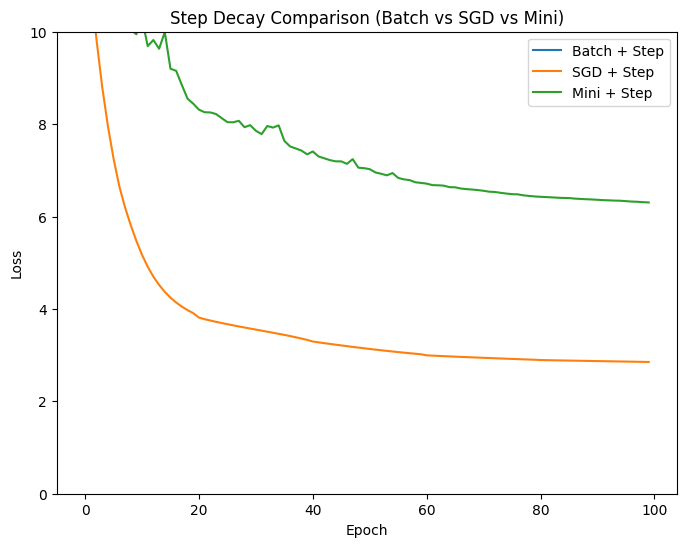

In [52]:
plt.figure(figsize=(8,6))

plt.plot(batch_step_loss[0], label="Batch + Step")
plt.plot(sgd_step_loss[0], label="SGD + Step")
plt.plot(mini_step_loss[0], label="Mini + Step")

plt.title("Step Decay Comparison (Batch vs SGD vs Mini)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 10)
plt.show()

In [53]:
# Batch Gradient Descent with Exponential Decay
# Learning rate decays exponentially over epochs

def train_batch_exp_decay(hidden_size=10, initial_lr=0.1,
                          decay_rate=0.05, epochs=100):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Exponential decay
        lr = initial_lr * np.exp(-decay_rate * epoch)

        # Forward
        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
batch_exp_loss = train_batch_exp_decay()

Epoch 0, LR: 0.10000, Loss: 708.0997366334449
Epoch 10, LR: 0.06065, Loss: 15.039946264606526
Epoch 20, LR: 0.03679, Loss: 14.61646742439165
Epoch 30, LR: 0.02231, Loss: 14.287145634518003
Epoch 40, LR: 0.01353, Loss: 14.010643621141481
Epoch 50, LR: 0.00821, Loss: 13.810907626689186
Epoch 60, LR: 0.00498, Loss: 13.67921804214216
Epoch 70, LR: 0.00302, Loss: 13.596117405600005
Epoch 80, LR: 0.00183, Loss: 13.544719294941748
Epoch 90, LR: 0.00111, Loss: 13.513226668913447


In [54]:
# SGD with Exponential Decay

def train_sgd_exp_decay(hidden_size=10, initial_lr=0.01,
                        decay_rate=0.05, epochs=100):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        lr = initial_lr * np.exp(-decay_rate * epoch)

        for i in range(X_train_scaled.shape[0]):

            x_i = X_train_scaled[i:i+1]
            y_i = y_train[i:i+1]

            # Forward
            Z1 = np.dot(x_i, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            dZ2 = (y_pred - y_i)
            dW2 = np.dot(A1.T, dZ2)
            db2 = dZ2

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(x_i.T, dZ1)
            db1 = dZ1

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Full loss
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
sgd_exp_loss = train_sgd_exp_decay()

Epoch 0, LR: 0.01000, Loss: 11.669174066939247
Epoch 10, LR: 0.00607, Loss: 5.6237796483328655
Epoch 20, LR: 0.00368, Loss: 4.373902678127178
Epoch 30, LR: 0.00223, Loss: 4.004322303805231
Epoch 40, LR: 0.00135, Loss: 3.8412518717813793
Epoch 50, LR: 0.00082, Loss: 3.7611770001411706
Epoch 60, LR: 0.00050, Loss: 3.7182684543584337
Epoch 70, LR: 0.00030, Loss: 3.6935882577859993
Epoch 80, LR: 0.00018, Loss: 3.678995436890807
Epoch 90, LR: 0.00011, Loss: 3.670282537629769


In [55]:
# Mini-Batch Gradient Descent with Exponential Decay

def train_minibatch_exp_decay(hidden_size=10, initial_lr=0.05,
                              decay_rate=0.05, epochs=100, batch_size=32):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        lr = initial_lr * np.exp(-decay_rate * epoch)

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Forward
            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Full loss
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
mini_exp_loss = train_minibatch_exp_decay()

Epoch 0, LR: 0.05000, Loss: 15.334743278546357
Epoch 10, LR: 0.03033, Loss: 10.182413170882977
Epoch 20, LR: 0.01839, Loss: 9.302999495727537
Epoch 30, LR: 0.01116, Loss: 8.839033467632392
Epoch 40, LR: 0.00677, Loss: 8.618699051471234
Epoch 50, LR: 0.00410, Loss: 8.45265413559066
Epoch 60, LR: 0.00249, Loss: 8.374391746759203
Epoch 70, LR: 0.00151, Loss: 8.327923736824538
Epoch 80, LR: 0.00092, Loss: 8.301770423852137
Epoch 90, LR: 0.00056, Loss: 8.286619730434923


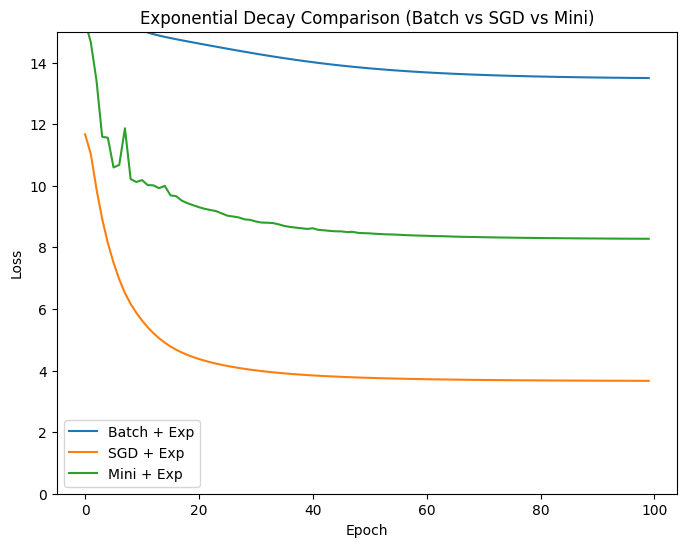

In [56]:
plt.figure(figsize=(8,6))

plt.plot(batch_exp_loss[0], label="Batch + Exp")
plt.plot(sgd_exp_loss[0], label="SGD + Exp")
plt.plot(mini_exp_loss[0], label="Mini + Exp")

plt.title("Exponential Decay Comparison (Batch vs SGD vs Mini)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 15)
plt.show()

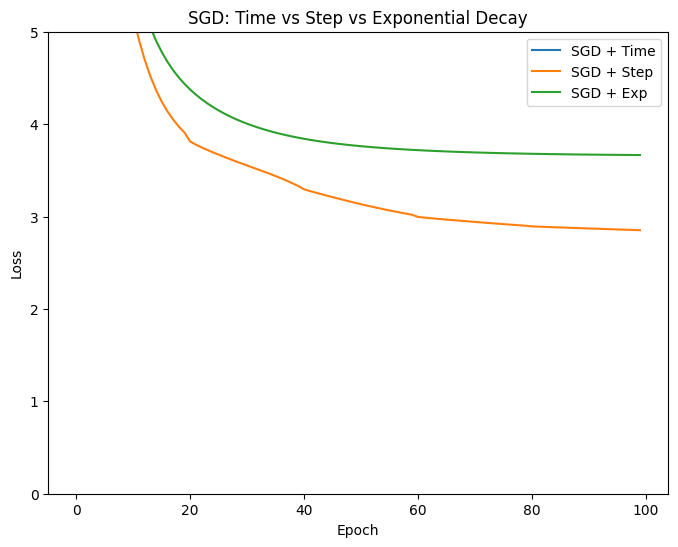

In [57]:
plt.figure(figsize=(8,6))

plt.plot(sgd_time_loss[0], label="SGD + Time")
plt.plot(sgd_step_loss[0], label="SGD + Step")
plt.plot(sgd_exp_loss[0], label="SGD + Exp")

plt.title("SGD: Time vs Step vs Exponential Decay")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 5)
plt.show()

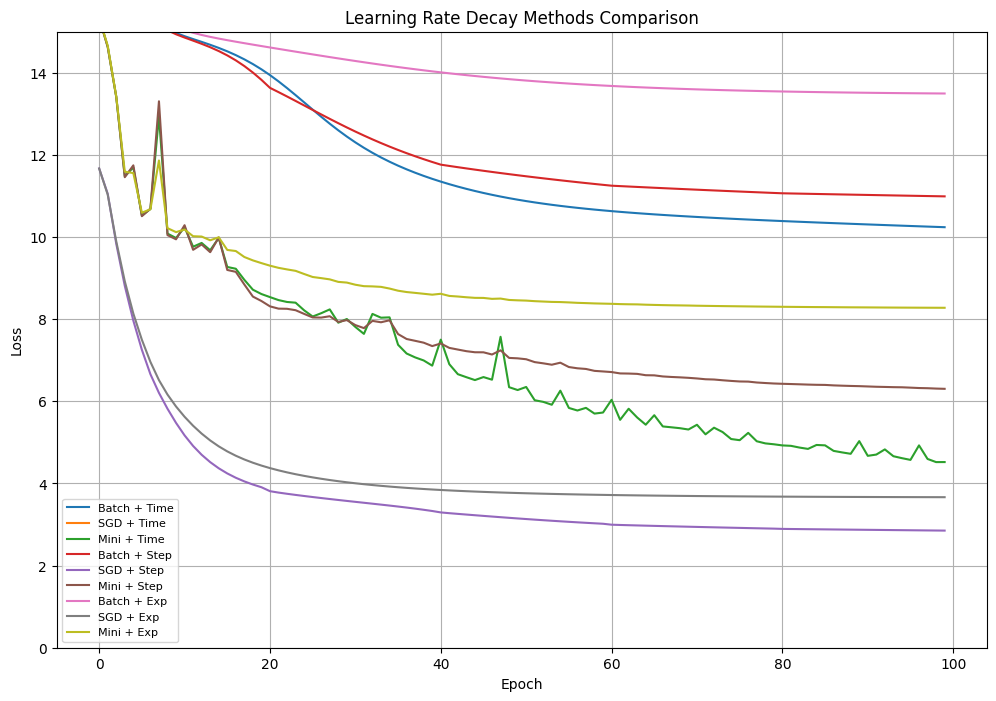

In [58]:
plt.figure(figsize=(12,8))

# ===== TIME DECAY =====
plt.plot(batch_time_loss[0], label="Batch + Time")
plt.plot(sgd_time_loss[0], label="SGD + Time")
plt.plot(mini_time_loss[0], label="Mini + Time")

# ===== STEP DECAY =====
plt.plot(batch_step_loss[0], label="Batch + Step")
plt.plot(sgd_step_loss[0], label="SGD + Step")
plt.plot(mini_step_loss[0], label="Mini + Step")

# ===== EXPONENTIAL DECAY =====
plt.plot(batch_exp_loss[0], label="Batch + Exp")
plt.plot(sgd_exp_loss[0], label="SGD + Exp")
plt.plot(mini_exp_loss[0], label="Mini + Exp")

plt.title("Learning Rate Decay Methods Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(fontsize=8)
plt.ylim(0, 15)
plt.grid(True)

plt.show()

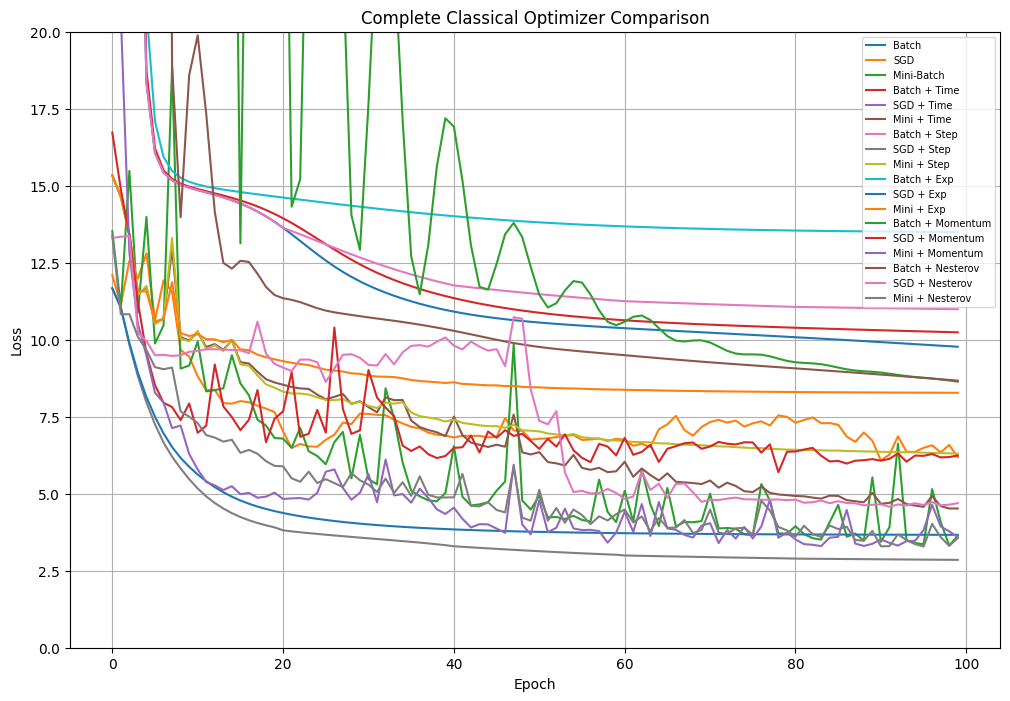

In [59]:
plt.figure(figsize=(12,8))

# ================= BASELINE =================
plt.plot(batch_loss[0], label="Batch")
plt.plot(sgd_loss[0], label="SGD")
plt.plot(mini_loss[0], label="Mini-Batch")

# ================= TIME DECAY =================
plt.plot(batch_time_loss[0], label="Batch + Time")
plt.plot(sgd_time_loss[0], label="SGD + Time")
plt.plot(mini_time_loss[0], label="Mini + Time")

# ================= STEP DECAY =================
plt.plot(batch_step_loss[0], label="Batch + Step")
plt.plot(sgd_step_loss[0], label="SGD + Step")
plt.plot(mini_step_loss[0], label="Mini + Step")

# ================= EXP DECAY =================
plt.plot(batch_exp_loss[0], label="Batch + Exp")
plt.plot(sgd_exp_loss[0], label="SGD + Exp")
plt.plot(mini_exp_loss[0], label="Mini + Exp")

# ================= MOMENTUM =================
plt.plot(batch_momentum_loss[0], label="Batch + Momentum")
plt.plot(sgd_momentum_loss[0], label="SGD + Momentum")
plt.plot(momentum_loss[0], label="Mini + Momentum")

# ================= NESTEROV =================
plt.plot(batch_nesterov_loss[0], label="Batch + Nesterov")
plt.plot(sgd_nesterov_loss[0], label="SGD + Nesterov")
plt.plot(mini_nesterov_loss[0], label="Mini + Nesterov")

plt.title("Complete Classical Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right", fontsize=7)
plt.ylim(0, 20)
plt.grid(True)

plt.show()

In [60]:
# =====================================================
# Mini-Batch AdaGrad Optimizer
# Adaptive learning rate based on accumulated squared gradients
# =====================================================

def train_adagrad(hidden_size=10, lr=0.01, epochs=100,
                  batch_size=32, epsilon=1e-8):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    GW1 = np.zeros_like(W1)
    Gb1 = np.zeros_like(b1)
    GW2 = np.zeros_like(W2)
    Gb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            GW2 += dW2**2
            Gb2 += db2**2
            GW1 += dW1**2
            Gb1 += db1**2

            W2 -= lr * dW2 / (np.sqrt(GW2) + epsilon)
            b2 -= lr * db2 / (np.sqrt(Gb2) + epsilon)
            W1 -= lr * dW1 / (np.sqrt(GW1) + epsilon)
            b1 -= lr * db1 / (np.sqrt(Gb1) + epsilon)

        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred)**2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


adagrad_loss = train_adagrad()

Epoch 0, Loss: 684.063588792035
Epoch 10, Loss: 606.4527059877528
Epoch 20, Loss: 562.1950762783496
Epoch 30, Loss: 528.2873440886989
Epoch 40, Loss: 499.8845321751228
Epoch 50, Loss: 474.82565720200273
Epoch 60, Loss: 452.31633768432476
Epoch 70, Loss: 431.6819760100589
Epoch 80, Loss: 412.7910029476318
Epoch 90, Loss: 395.32969774206913


In [61]:
# =====================================================
# Mini-Batch RMSProp Optimizer
# Exponential moving average of squared gradients
# =====================================================

def train_rmsprop(hidden_size=10, lr=0.001, epochs=100,
                  batch_size=32, beta=0.9, epsilon=1e-8):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            vW2 = beta * vW2 + (1-beta) * dW2**2
            vb2 = beta * vb2 + (1-beta) * db2**2
            vW1 = beta * vW1 + (1-beta) * dW1**2
            vb1 = beta * vb1 + (1-beta) * db1**2

            W2 -= lr * dW2 / (np.sqrt(vW2) + epsilon)
            b2 -= lr * db2 / (np.sqrt(vb2) + epsilon)
            W1 -= lr * dW1 / (np.sqrt(vW1) + epsilon)
            b1 -= lr * db1 / (np.sqrt(vb1) + epsilon)

        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred)**2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


rmsprop_loss = train_rmsprop()

Epoch 0, Loss: 699.1006457344116
Epoch 10, Loss: 630.1760498380955
Epoch 20, Loss: 555.8885964643812
Epoch 30, Loss: 482.60589969268386
Epoch 40, Loss: 410.7135348108531
Epoch 50, Loss: 341.0641027629121
Epoch 60, Loss: 275.8406137576601
Epoch 70, Loss: 216.7607110910629
Epoch 80, Loss: 165.64702046374902
Epoch 90, Loss: 123.08421877704994


In [62]:
# =====================================================
# Mini-Batch Adam Optimizer
# Combines Momentum and RMSProp with bias correction
# =====================================================

def train_adam(hidden_size=10, lr=0.001, epochs=100,
               batch_size=32, beta1=0.9, beta2=0.999, epsilon=1e-8):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    mW1 = np.zeros_like(W1)
    vW1 = np.zeros_like(W1)
    mb1 = np.zeros_like(b1)
    vb1 = np.zeros_like(b1)

    mW2 = np.zeros_like(W2)
    vW2 = np.zeros_like(W2)
    mb2 = np.zeros_like(b2)
    vb2 = np.zeros_like(b2)

    loss_history = []
    t = 0

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            t += 1
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            mW2 = beta1 * mW2 + (1-beta1) * dW2
            vW2 = beta2 * vW2 + (1-beta2) * dW2**2
            mb2 = beta1 * mb2 + (1-beta1) * db2
            vb2 = beta2 * vb2 + (1-beta2) * db2**2

            mW1 = beta1 * mW1 + (1-beta1) * dW1
            vW1 = beta2 * vW1 + (1-beta2) * dW1**2
            mb1 = beta1 * mb1 + (1-beta1) * db1
            vb1 = beta2 * vb1 + (1-beta2) * db1**2

            mW2_hat = mW2 / (1 - beta1**t)
            vW2_hat = vW2 / (1 - beta2**t)
            mb2_hat = mb2 / (1 - beta1**t)
            vb2_hat = vb2 / (1 - beta2**t)

            mW1_hat = mW1 / (1 - beta1**t)
            vW1_hat = vW1 / (1 - beta2**t)
            mb1_hat = mb1 / (1 - beta1**t)
            vb1_hat = vb1 / (1 - beta2**t)

            W2 -= lr * mW2_hat / (np.sqrt(vW2_hat) + epsilon)
            b2 -= lr * mb2_hat / (np.sqrt(vb2_hat) + epsilon)
            W1 -= lr * mW1_hat / (np.sqrt(vW1_hat) + epsilon)
            b1 -= lr * mb1_hat / (np.sqrt(vb1_hat) + epsilon)

        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred)**2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


adam_loss = train_adam()

Epoch 0, Loss: 701.8132914909817
Epoch 10, Loss: 630.6229975518302
Epoch 20, Loss: 549.8480410427862
Epoch 30, Loss: 471.1599603650241
Epoch 40, Loss: 394.68135799280714
Epoch 50, Loss: 325.1365365006525
Epoch 60, Loss: 265.668315068305
Epoch 70, Loss: 216.0569383519174
Epoch 80, Loss: 175.77214390552544
Epoch 90, Loss: 143.31364915263075


In [63]:
# =====================================================
# Mini-Batch Adamax Optimizer
# Variant of Adam using infinity norm
# =====================================================

def train_adamax(hidden_size=10, lr=0.002, epochs=100,
                 batch_size=32, beta1=0.9, beta2=0.999, epsilon=1e-8):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    mW1 = np.zeros_like(W1)
    uW1 = np.zeros_like(W1)
    mb1 = np.zeros_like(b1)
    ub1 = np.zeros_like(b1)

    mW2 = np.zeros_like(W2)
    uW2 = np.zeros_like(W2)
    mb2 = np.zeros_like(b2)
    ub2 = np.zeros_like(b2)

    loss_history = []
    t = 0

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            t += 1
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # First moment
            mW2 = beta1 * mW2 + (1-beta1) * dW2
            mb2 = beta1 * mb2 + (1-beta1) * db2
            mW1 = beta1 * mW1 + (1-beta1) * dW1
            mb1 = beta1 * mb1 + (1-beta1) * db1

            # Infinity norm
            uW2 = np.maximum(beta2 * uW2, np.abs(dW2))
            ub2 = np.maximum(beta2 * ub2, np.abs(db2))
            uW1 = np.maximum(beta2 * uW1, np.abs(dW1))
            ub1 = np.maximum(beta2 * ub1, np.abs(db1))

            # Bias correction
            mW2_hat = mW2 / (1 - beta1**t)
            mb2_hat = mb2 / (1 - beta1**t)
            mW1_hat = mW1 / (1 - beta1**t)
            mb1_hat = mb1 / (1 - beta1**t)

            # Update
            W2 -= lr * mW2_hat / (uW2 + epsilon)
            b2 -= lr * mb2_hat / (ub2 + epsilon)
            W1 -= lr * mW1_hat / (uW1 + epsilon)
            b1 -= lr * mb1_hat / (ub1 + epsilon)

        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred)**2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


adamax_loss = train_adamax()

Epoch 0, Loss: 697.2068750275808
Epoch 10, Loss: 589.628313245912
Epoch 20, Loss: 475.5481262330405
Epoch 30, Loss: 364.22374471004207
Epoch 40, Loss: 258.7899997875461
Epoch 50, Loss: 183.97983961646173
Epoch 60, Loss: 128.86339755148396
Epoch 70, Loss: 88.91271948281256
Epoch 80, Loss: 60.64811488995863
Epoch 90, Loss: 42.08422777120358


In [64]:
# =====================================================
# Mini-Batch Adadelta Optimizer
# Adaptive method without manual learning rate
# =====================================================

def train_adadelta(hidden_size=10, epochs=100,
                   batch_size=32, rho=0.95, epsilon=1e-6):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    EgW1 = np.zeros_like(W1)
    Egb1 = np.zeros_like(b1)
    EgW2 = np.zeros_like(W2)
    Egb2 = np.zeros_like(b2)

    EdW1 = np.zeros_like(W1)
    Edb1 = np.zeros_like(b1)
    EdW2 = np.zeros_like(W2)
    Edb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Accumulate gradient
            EgW2 = rho * EgW2 + (1-rho) * dW2**2
            Egb2 = rho * Egb2 + (1-rho) * db2**2
            EgW1 = rho * EgW1 + (1-rho) * dW1**2
            Egb1 = rho * Egb1 + (1-rho) * db1**2

            # Compute update
            delta_W2 = - (np.sqrt(EdW2 + epsilon) / np.sqrt(EgW2 + epsilon)) * dW2
            delta_b2 = - (np.sqrt(Edb2 + epsilon) / np.sqrt(Egb2 + epsilon)) * db2
            delta_W1 = - (np.sqrt(EdW1 + epsilon) / np.sqrt(EgW1 + epsilon)) * dW1
            delta_b1 = - (np.sqrt(Edb1 + epsilon) / np.sqrt(Egb1 + epsilon)) * db1

            # Apply update
            W2 += delta_W2
            b2 += delta_b2
            W1 += delta_W1
            b1 += delta_b1

            # Accumulate updates
            EdW2 = rho * EdW2 + (1-rho) * delta_W2**2
            Edb2 = rho * Edb2 + (1-rho) * delta_b2**2
            EdW1 = rho * EdW1 + (1-rho) * delta_W1**2
            Edb1 = rho * Edb1 + (1-rho) * delta_b1**2

        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred)**2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


adadelta_loss, W1_ad, b1_ad, W2_ad, b2_ad = train_adadelta()

Epoch 0, Loss: 679.1862728443235
Epoch 10, Loss: 240.54320396377375
Epoch 20, Loss: 87.15621558166855
Epoch 30, Loss: 31.4608489856531
Epoch 40, Loss: 17.210173221862163
Epoch 50, Loss: 16.266000821019688
Epoch 60, Loss: 16.220028755087046
Epoch 70, Loss: 16.202056644393156
Epoch 80, Loss: 16.223568718870276
Epoch 90, Loss: 16.014876330200263


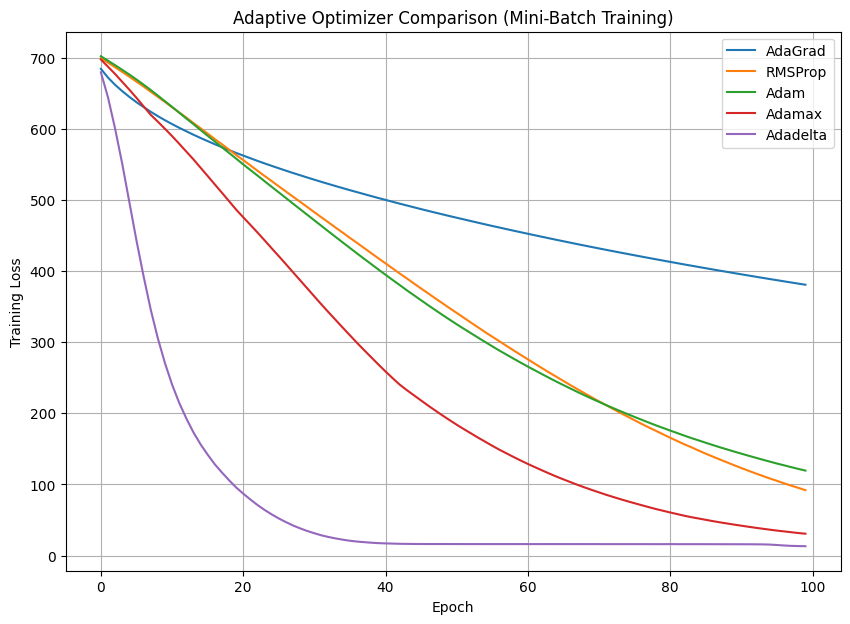

In [65]:
plt.figure(figsize=(10,7))

plt.plot(adagrad_loss[0], label="AdaGrad")
plt.plot(rmsprop_loss[0], label="RMSProp")
plt.plot(adam_loss[0], label="Adam")
plt.plot(adamax_loss[0], label="Adamax")
plt.plot(adadelta_loss, label="Adadelta")

plt.title("Adaptive Optimizer Comparison (Mini-Batch Training)")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)

plt.show()

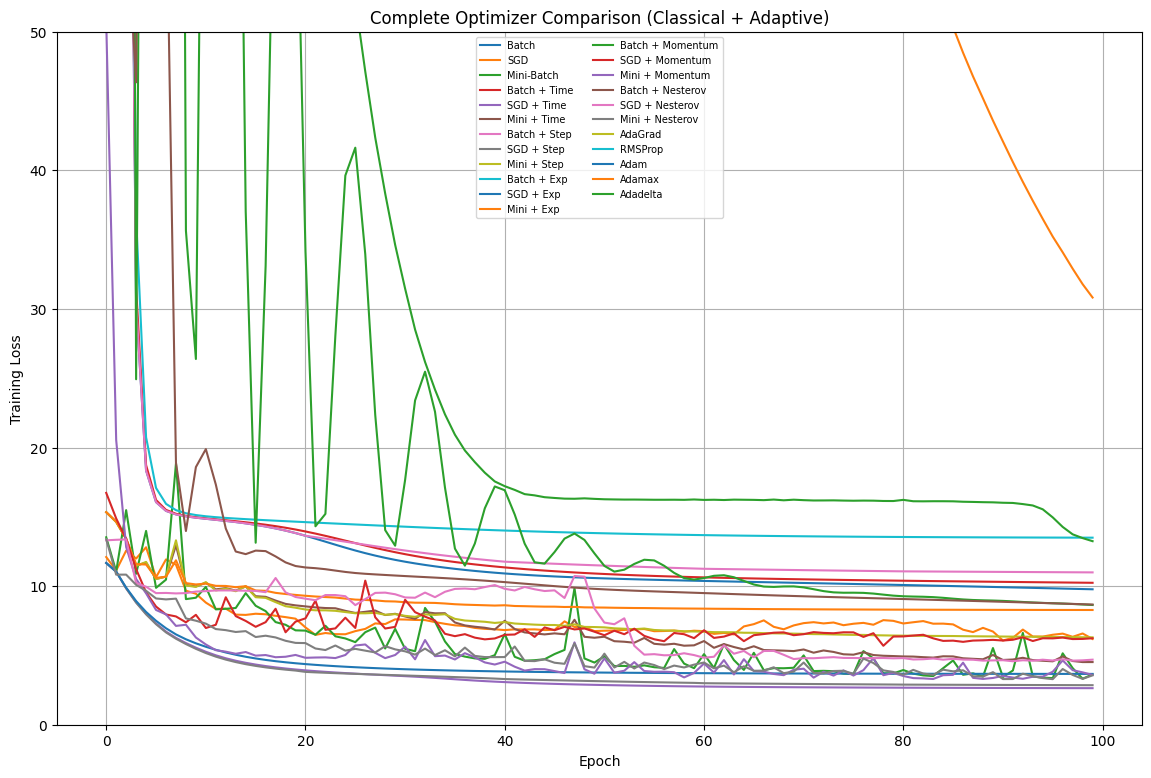

In [66]:
plt.figure(figsize=(14,9))

# ================= BASELINE =================
plt.plot(batch_loss[0], label="Batch")
plt.plot(sgd_loss[0], label="SGD")
plt.plot(mini_loss[0], label="Mini-Batch")

# ================= TIME DECAY =================
plt.plot(batch_time_loss[0], label="Batch + Time")
plt.plot(sgd_time_loss, label="SGD + Time")
plt.plot(mini_time_loss[0], label="Mini + Time")

# ================= STEP DECAY =================
plt.plot(batch_step_loss[0], label="Batch + Step")
plt.plot(sgd_step_loss[0], label="SGD + Step")
plt.plot(mini_step_loss[0], label="Mini + Step")

# ================= EXP DECAY =================
plt.plot(batch_exp_loss[0], label="Batch + Exp")
plt.plot(sgd_exp_loss[0], label="SGD + Exp")
plt.plot(mini_exp_loss[0], label="Mini + Exp")

# ================= MOMENTUM =================
plt.plot(batch_momentum_loss[0], label="Batch + Momentum")
plt.plot(sgd_momentum_loss[0], label="SGD + Momentum")
plt.plot(momentum_loss[0], label="Mini + Momentum")

# ================= NESTEROV =================
plt.plot(batch_nesterov_loss[0], label="Batch + Nesterov")
plt.plot(sgd_nesterov_loss[0], label="SGD + Nesterov")
plt.plot(mini_nesterov_loss[0], label="Mini + Nesterov")

# ================= ADAPTIVE =================
plt.plot(adagrad_loss[0], label="AdaGrad")
plt.plot(rmsprop_loss[0], label="RMSProp")
plt.plot(adam_loss[0], label="Adam")
plt.plot(adamax_loss[0], label="Adamax")
plt.plot(adadelta_loss, label="Adadelta")

plt.title("Complete Optimizer Comparison (Classical + Adaptive)")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend(fontsize=7, ncol=2)
plt.ylim(0, 50)
plt.grid(True)
plt.show()

In [67]:
# --- Final Evaluation: Train vs Test Loss for ALL optimizers in table format ---

def compute_loss(X, y, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
    Z2 = np.dot(A1, W2) + b2
    y_pred = Z2
    return np.mean((y - y_pred) ** 2)


# --- Run all and collect weights ---
batch_loss, W1_batch, b1_batch, W2_batch, b2_batch = train_batch()
sgd_loss, W1_sgd, b1_sgd, W2_sgd, b2_sgd = train_sgd()
mini_loss, W1_mini, b1_mini, W2_mini, b2_mini = train_minibatch()

batch_time_loss, W1_bt, b1_bt, W2_bt, b2_bt = train_batch_time_decay()
sgd_time_loss, W1_st, b1_st, W2_st, b2_st = train_sgd_time_decay()
mini_time_loss, W1_mt, b1_mt, W2_mt, b2_mt = train_minibatch_time_decay()

batch_step_loss, W1_bs, b1_bs, W2_bs, b2_bs = train_batch_step_decay()
sgd_step_loss, W1_ss, b1_ss, W2_ss, b2_ss = train_sgd_step_decay()
mini_step_loss, W1_ms, b1_ms, W2_ms, b2_ms = train_minibatch_step_decay()

batch_exp_loss, W1_be, b1_be, W2_be, b2_be = train_batch_exp_decay()
sgd_exp_loss, W1_se, b1_se, W2_se, b2_se = train_sgd_exp_decay()
mini_exp_loss, W1_me, b1_me, W2_me, b2_me = train_minibatch_exp_decay()

batch_momentum_loss, W1_bm, b1_bm, W2_bm, b2_bm = train_batch_momentum()
sgd_momentum_loss, W1_sm, b1_sm, W2_sm, b2_sm = train_sgd_momentum()
momentum_loss, W1_mm, b1_mm, W2_mm, b2_mm = train_momentum()

batch_nesterov_loss, W1_bn, b1_bn, W2_bn, b2_bn = train_batch_nesterov()
sgd_nesterov_loss, W1_sn, b1_sn, W2_sn, b2_sn = train_sgd_nesterov()
mini_nesterov_loss, W1_mn, b1_mn, W2_mn, b2_mn = train_minibatch_nesterov()

adagrad_loss, W1_ag, b1_ag, W2_ag, b2_ag = train_adagrad()
rmsprop_loss, W1_rp, b1_rp, W2_rp, b2_rp = train_rmsprop()
adam_loss, W1_ad, b1_ad, W2_ad, b2_ad = train_adam()
adamax_loss, W1_ax, b1_ax, W2_ax, b2_ax = train_adamax()
adadelta_loss, W1_aa, b1_aa, W2_aa, b2_aa = train_adadelta()


# --- Build results table ---
results = {
    "Batch"          : (batch_loss[-1],         compute_loss(X_test_scaled, y_test, W1_batch, b1_batch, W2_batch, b2_batch)),
    "SGD"            : (sgd_loss[-1],           compute_loss(X_test_scaled, y_test, W1_sgd,   b1_sgd,   W2_sgd,   b2_sgd)),
    "Mini-Batch"     : (mini_loss[-1],          compute_loss(X_test_scaled, y_test, W1_mini,  b1_mini,  W2_mini,  b2_mini)),

    "Batch+Time"     : (batch_time_loss[-1],    compute_loss(X_test_scaled, y_test, W1_bt,    b1_bt,    W2_bt,    b2_bt)),
    "SGD+Time"       : (sgd_time_loss[-1],      compute_loss(X_test_scaled, y_test, W1_st,    b1_st,    W2_st,    b2_st)),
    "Mini+Time"      : (mini_time_loss[-1],     compute_loss(X_test_scaled, y_test, W1_mt,    b1_mt,    W2_mt,    b2_mt)),

    "Batch+Step"     : (batch_step_loss[-1],    compute_loss(X_test_scaled, y_test, W1_bs,    b1_bs,    W2_bs,    b2_bs)),
    "SGD+Step"       : (sgd_step_loss[-1],      compute_loss(X_test_scaled, y_test, W1_ss,    b1_ss,    W2_ss,    b2_ss)),
    "Mini+Step"      : (mini_step_loss[-1],     compute_loss(X_test_scaled, y_test, W1_ms,    b1_ms,    W2_ms,    b2_ms)),

    "Batch+Exp"      : (batch_exp_loss[-1],     compute_loss(X_test_scaled, y_test, W1_be,    b1_be,    W2_be,    b2_be)),
    "SGD+Exp"        : (sgd_exp_loss[-1],       compute_loss(X_test_scaled, y_test, W1_se,    b1_se,    W2_se,    b2_se)),
    "Mini+Exp"       : (mini_exp_loss[-1],      compute_loss(X_test_scaled, y_test, W1_me,    b1_me,    W2_me,    b2_me)),

    "Batch+Momentum" : (batch_momentum_loss[-1],compute_loss(X_test_scaled, y_test, W1_bm,    b1_bm,    W2_bm,    b2_bm)),
    "SGD+Momentum"   : (sgd_momentum_loss[-1],  compute_loss(X_test_scaled, y_test, W1_sm,    b1_sm,    W2_sm,    b2_sm)),
    "Mini+Momentum"  : (momentum_loss[-1],      compute_loss(X_test_scaled, y_test, W1_mm,    b1_mm,    W2_mm,    b2_mm)),

    "Batch+Nesterov" : (batch_nesterov_loss[-1],compute_loss(X_test_scaled, y_test, W1_bn,    b1_bn,    W2_bn,    b2_bn)),
    "SGD+Nesterov"   : (sgd_nesterov_loss[-1],  compute_loss(X_test_scaled, y_test, W1_sn,    b1_sn,    W2_sn,    b2_sn)),
    "Mini+Nesterov"  : (mini_nesterov_loss[-1], compute_loss(X_test_scaled, y_test, W1_mn,    b1_mn,    W2_mn,    b2_mn)),

    "AdaGrad"        : (adagrad_loss[-1],       compute_loss(X_test_scaled, y_test, W1_ag,    b1_ag,    W2_ag,    b2_ag)),
    "RMSProp"        : (rmsprop_loss[-1],       compute_loss(X_test_scaled, y_test, W1_rp,    b1_rp,    W2_rp,    b2_rp)),
    "Adam"           : (adam_loss[-1],          compute_loss(X_test_scaled, y_test, W1_ad,    b1_ad,    W2_ad,    b2_ad)),
    "Adamax"         : (adamax_loss[-1],        compute_loss(X_test_scaled, y_test, W1_ax,    b1_ax,    W2_ax,    b2_ax)),
    "Adadelta"       : (adadelta_loss[-1],      compute_loss(X_test_scaled, y_test, W1_aa,    b1_aa,    W2_aa,    b2_aa)),
}


# --- Sort results (BEST ON TOP) ---
sorted_results = sorted(results.items(), key=lambda x: x[1][1])

# --- Print table ---
print(f"\n{'Optimizer':<20} {'Train Loss':>12} {'Test Loss':>12} {'Difference':>12}")
print("=" * 60)

for name, (train, test) in sorted_results:
    diff = abs(test - train)
    print(f"{name:<20} {train:>12.4f} {test:>12.4f} {diff:>12.4f}")


# --- Find best optimizer ---
best = sorted_results[0]

print(f"\n Best Optimizer for Cooling Load: {best[0]}")
print(f" Train Loss: {best[1][0]:.4f} | Test Loss: {best[1][1]:.4f}")

Epoch 0, Loss: 708.0997
  W1 (8→10):
[[ 4.630e-02 -8.400e-03  8.740e-02  1.452e-01 -3.560e-02 -3.100e-02
   1.714e-01  8.150e-02 -5.490e-02  6.200e-02]
 [-4.280e-02 -5.230e-02  2.000e-04 -1.836e-01 -1.596e-01 -4.820e-02
  -1.157e-01  2.630e-02 -8.230e-02 -1.494e-01]
 [ 1.445e-01 -1.910e-02  2.140e-02 -1.475e-01 -6.200e-02  6.100e-03
  -1.063e-01  4.070e-02 -6.530e-02 -2.420e-02]
 [-5.570e-02  1.779e-01 -3.190e-02 -9.580e-02  9.860e-02 -1.118e-01
   2.500e-03 -2.025e-01 -1.219e-01  9.300e-03]
 [ 6.920e-02  2.480e-02  2.020e-02 -4.080e-02 -1.648e-01 -8.270e-02
  -2.670e-02  1.126e-01  2.300e-02 -1.655e-01]
 [ 3.240e-02 -3.840e-02 -6.730e-02  6.110e-02  1.028e-01  9.300e-02
  -8.360e-02 -3.080e-02  3.300e-02  9.780e-02]
 [-4.920e-02 -1.650e-02 -1.022e-01 -1.225e-01  7.660e-02  1.328e-01
  -2.100e-03  1.020e-01  3.320e-02 -6.160e-02]
 [ 3.590e-02  1.542e-01 -2.100e-03  1.561e-01 -2.624e-01  8.170e-02
   9.600e-03 -2.960e-02  8.700e-03 -1.983e-01]]
  W2 (10→1):
[[1.2742]
 [1.2456]
 [1.3865]

Best Optimizer: SGD + Time Decay

Test Loss ≈ 0.54

Very small train–test difference → no overfitting

In [68]:
# --- Final predictions on test set using best optimizer (SGD + Time Decay) ---

Z1 = np.dot(X_test_scaled, W1_st) + b1_st
A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
Z2 = np.dot(A1, W2_st) + b2_st
y_pred_test = Z2

print("First 10 Predictions vs Actual (Cooling Load):\n")

for i in range(10):
    print(f"Actual: {y_test[i][0]:.3f} | Predicted: {y_pred_test[i][0]:.3f}")

# Compute RMSE
test_loss_sgd_time = compute_loss(X_test_scaled, y_test, W1_st, b1_st, W2_st, b2_st)
rmse_sgd = np.sqrt(test_loss_sgd_time)

print("\nSGD + Time Decay Test RMSE (Cooling):", round(rmse_sgd, 4))

First 10 Predictions vs Actual (Cooling Load):

Actual: 34.520 | Predicted: 32.001
Actual: 14.580 | Predicted: 14.616
Actual: 17.640 | Predicted: 17.337
Actual: 18.360 | Predicted: 17.754
Actual: 39.670 | Predicted: 39.484
Actual: 16.990 | Predicted: 16.750
Actual: 16.600 | Predicted: 16.661
Actual: 17.100 | Predicted: 16.905
Actual: 33.130 | Predicted: 33.283
Actual: 13.720 | Predicted: 14.047

SGD + Time Decay Test RMSE (Cooling): 1.4925


In [69]:
W1[0,0]
W1[1,0]
# Select two weights to vary
w1_original = W1_sgd.copy()
b1_original = b1_sgd.copy()
W2_original = W2_sgd.copy()
b2_original = b2_sgd.copy()

# Define range for weight variation
w1_range = np.linspace(w1_original[0,0] - 1, w1_original[0,0] + 1, 50)
w2_range = np.linspace(w1_original[1,0] - 1, w1_original[1,0] + 1, 50)

loss_surface = np.zeros((len(w1_range), len(w2_range)))

# Compute loss grid
for i in range(len(w1_range)):
    for j in range(len(w2_range)):

        W1_temp = w1_original.copy()
        W1_temp[0,0] = w1_range[i]
        W1_temp[1,0] = w2_range[j]

        # Forward pass
        Z1 = np.dot(X_train_scaled, W1_temp) + b1_original
        A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
        Z2 = np.dot(A1, W2_original) + b2_original
        y_pred = Z2

        loss_surface[i,j] = np.mean((y_train - y_pred)**2)

print("Loss surface computed successfully.")

Loss surface computed successfully.


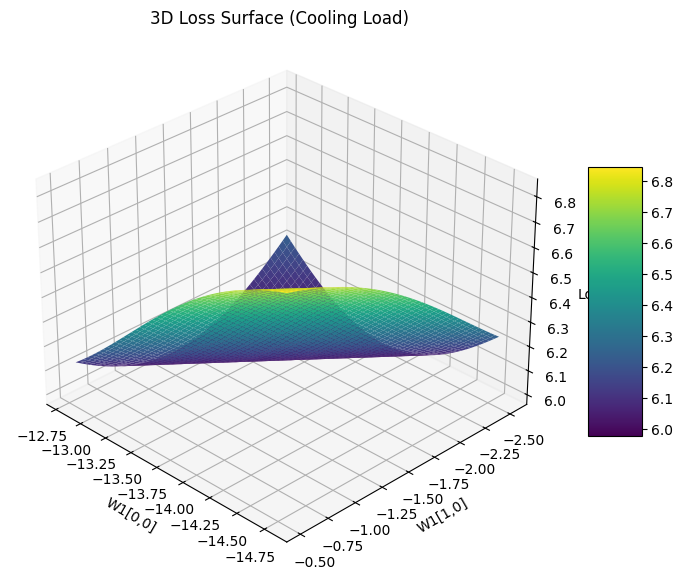

In [70]:
from mpl_toolkits.mplot3d import Axes3D

W1_grid, W2_grid = np.meshgrid(w1_range, w2_range)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(W1_grid, W2_grid, loss_surface.T, cmap='viridis', edgecolor='none')

# Add color bar
fig.colorbar(surface, shrink=0.5, aspect=5)

ax.set_title("3D Loss Surface (Cooling Load)")
ax.set_xlabel("W1[0,0]")
ax.set_ylabel("W1[1,0]")
ax.set_zlabel("Loss")

# Better viewing angle
ax.view_init(elev=30, azim=135)

plt.show()

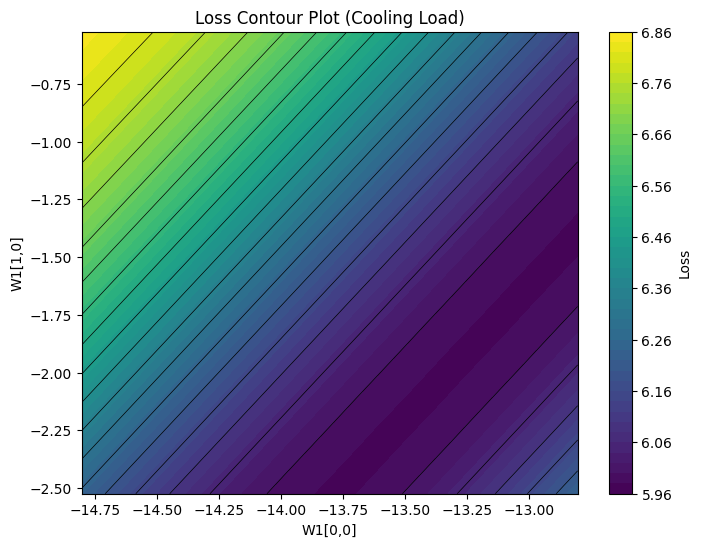

In [71]:
plt.figure(figsize=(8,6))

# Filled contour
contour = plt.contourf(W1_grid, W2_grid, loss_surface.T, levels=50, cmap='viridis')

# Optional: contour lines on top
plt.contour(W1_grid, W2_grid, loss_surface.T, levels=20, colors='black', linewidths=0.5)

plt.title("Loss Contour Plot (Cooling Load)")
plt.xlabel("W1[0,0]")
plt.ylabel("W1[1,0]")

plt.colorbar(contour, label="Loss")

plt.show()

Activation   LR         Train Loss    Test Loss
relu         0.001         10.6498      10.6892
relu         0.01           9.3308       9.5982
relu         0.1               nan          nan
sigmoid      0.001         14.9568      15.1849
sigmoid      0.01           9.1116       8.8670
sigmoid      0.1            3.7836       3.8004
tanh         0.001         15.5509      16.0637
tanh         0.01           4.6519       4.3145
tanh         0.1            4.2077       3.8093

 Best combination for Cooling Load: sigmoid_lr0.1
 Train Loss: 3.7836 | Test Loss: 3.8004


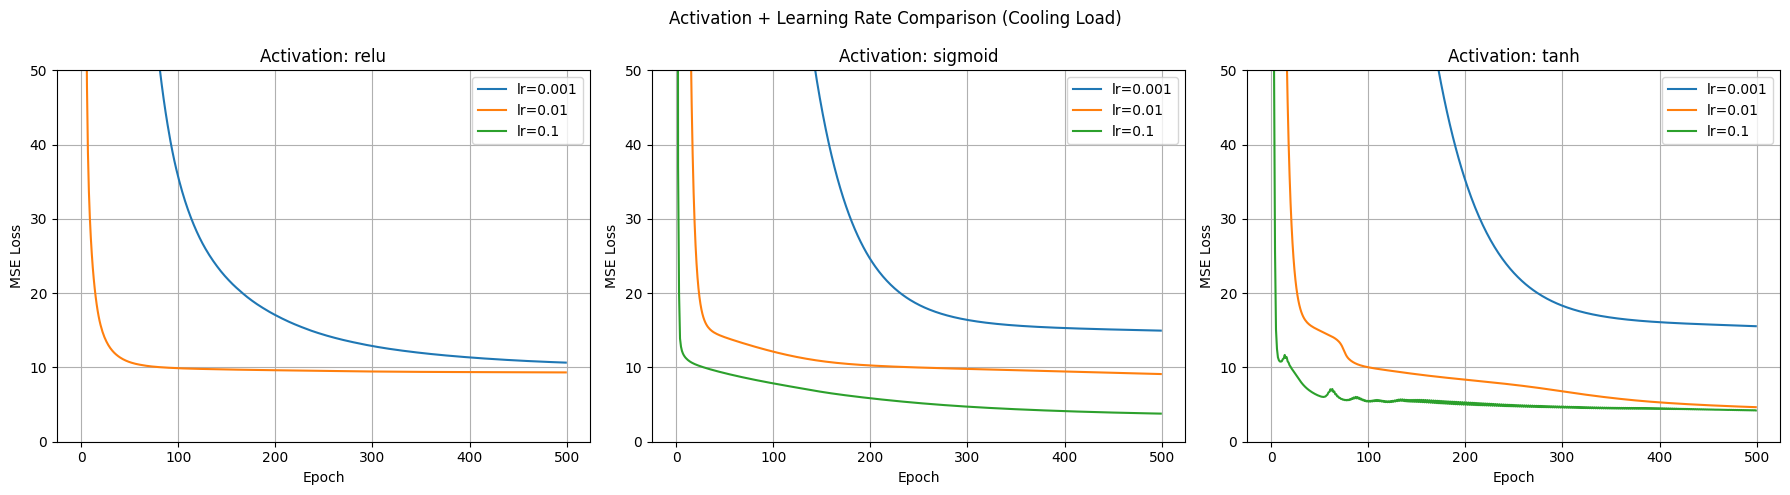

In [72]:
# ============================================================
# PHASE 1: Learning Rate + Activation Function Selection
# (Cooling Load Prediction)
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import random
import matplotlib.pyplot as plt

# --- Fix random seeds ---
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

results = {}
histories = {}

activations = ['relu', 'sigmoid', 'tanh']
learning_rates = [0.001, 0.01, 0.1]

print(f"{'Activation':<12} {'LR':<8} {'Train Loss':>12} {'Test Loss':>12}")
print("=" * 50)

for activation in activations:
    for lr in learning_rates:

        # Model
        model = keras.Sequential([
            keras.Input(shape=(8,)),
            layers.Dense(10, activation=activation),
            layers.Dense(1)   # regression output (Cooling Load)
        ])

        model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=lr),
            loss='mse'
        )

        # Training
        history = model.fit(
            X_train_scaled, y_train,
            epochs=500,
            batch_size=len(X_train_scaled),  # Batch GD
            verbose=0
        )

        train_loss = history.history['loss'][-1]
        test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

        key = f"{activation}_lr{lr}"
        results[key] = (train_loss, test_loss)
        histories[key] = history.history['loss']

        print(f"{activation:<12} {lr:<8} {train_loss:>12.4f} {test_loss:>12.4f}")

# --- Best combination ---
best = min(results, key=lambda x: results[x][1])

print(f"\n Best combination for Cooling Load: {best}")
print(f" Train Loss: {results[best][0]:.4f} | Test Loss: {results[best][1]:.4f}")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, activation in enumerate(activations):
    for lr in learning_rates:
        key = f"{activation}_lr{lr}"
        axes[idx].plot(histories[key], label=f"lr={lr}")

    axes[idx].set_title(f"Activation: {activation}")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")
    axes[idx].set_ylim(0, 50)
    axes[idx].legend()
    axes[idx].grid(True)

plt.suptitle("Activation + Learning Rate Comparison (Cooling Load)")
plt.tight_layout()
plt.show()

Architecture         Layers   Neurons                Train Loss    Test Loss     Diff
1L [8]               1        [8]                        3.7960       3.5852   0.2109
1L [16]              1        [16]                       3.5760       3.5716   0.0043
1L [32]              1        [32]                       6.0729       6.3722   0.2993
2L [16→8]            2        [16, 8]                    4.5314       3.9263   0.6051
2L [32→16]           2        [32, 16]                   5.1089       5.0394   0.0695
2L [32→8]            2        [32, 8]                    5.2219       4.9567   0.2653
2L [64→32]           2        [64, 32]                   5.5770       5.6470   0.0700
3L [32→16→8]         3        [32, 16, 8]                8.3838       8.1179   0.2659
3L [64→32→16]        3        [64, 32, 16]               6.2047       5.4036   0.8011
3L [16→8→4]          3        [16, 8, 4]                 6.0047       6.3284   0.3237
4L [64→32→16→8]      4        [64, 32, 16, 8]         

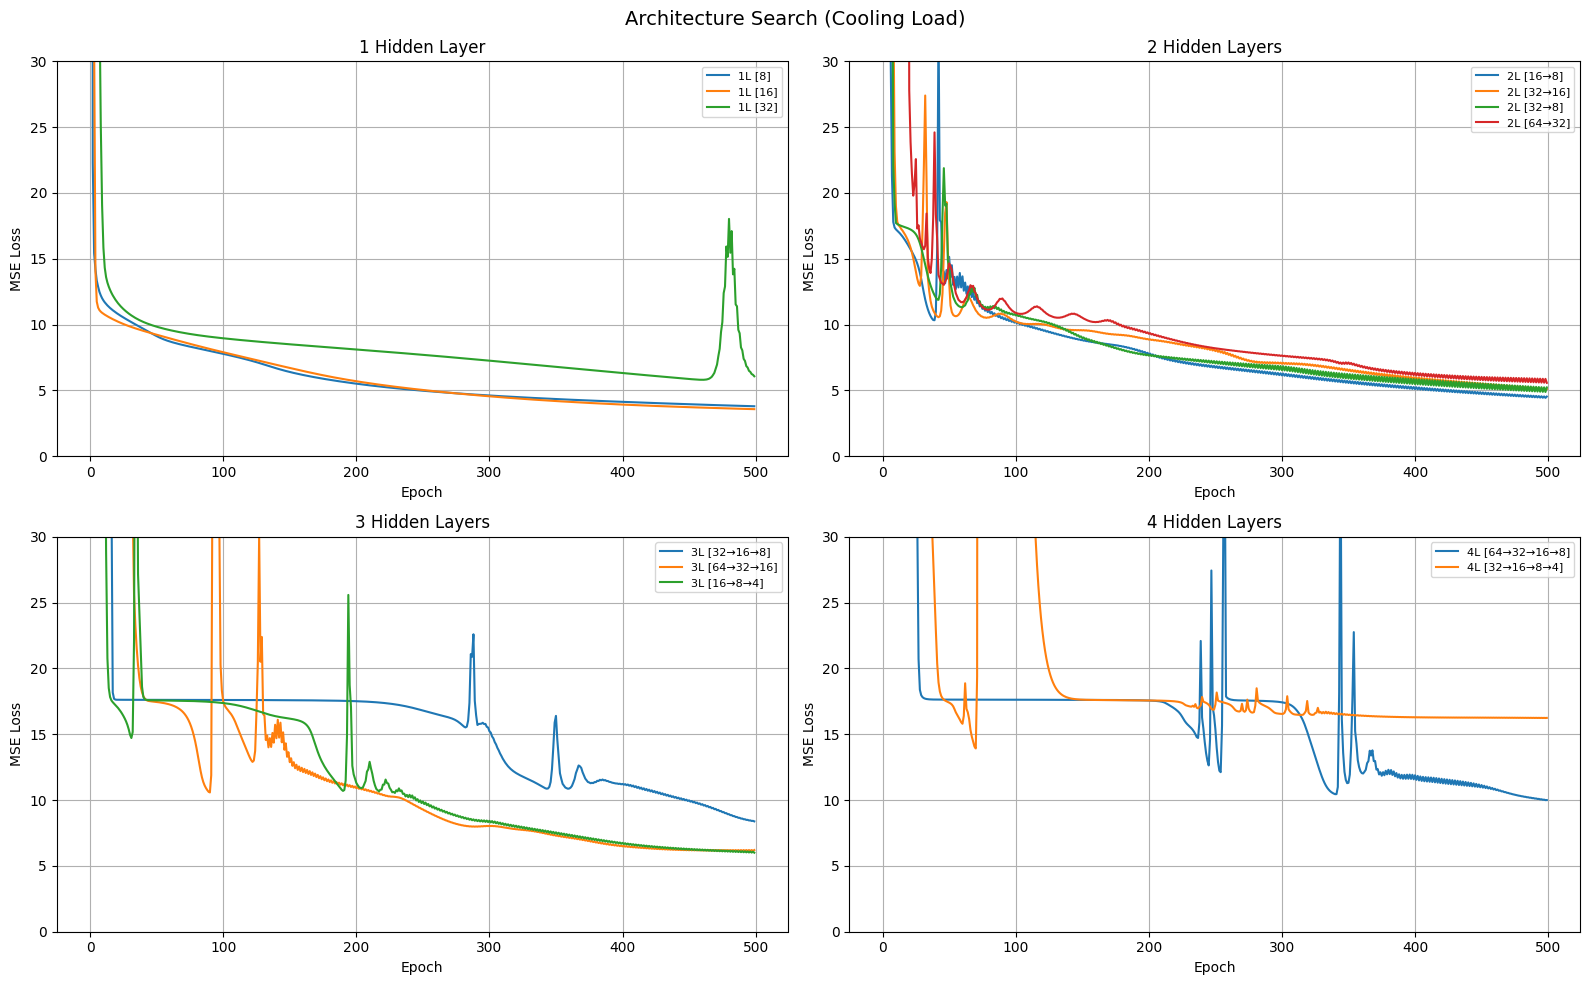

In [73]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import random
import matplotlib.pyplot as plt

# --- Seeds ---
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

architectures = {
    "1L [8]"       : [8],
    "1L [16]"      : [16],
    "1L [32]"      : [32],

    "2L [16→8]"    : [16, 8],
    "2L [32→16]"   : [32, 16],
    "2L [32→8]"    : [32, 8],
    "2L [64→32]"   : [64, 32],

    "3L [32→16→8]" : [32, 16, 8],
    "3L [64→32→16]": [64, 32, 16],
    "3L [16→8→4]"  : [16, 8, 4],

    "4L [64→32→16→8]" : [64, 32, 16, 8],
    "4L [32→16→8→4]"  : [32, 16, 8, 4],
}

arch_results = {}
arch_histories = {}

print(f"{'Architecture':<20} {'Layers':<8} {'Neurons':<20} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>8}")
print("=" * 85)

for name, arch in architectures.items():

    model = keras.Sequential()
    model.add(keras.Input(shape=(8,)))

    for neurons in arch:
        model.add(layers.Dense(neurons, activation='sigmoid'))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.1),
        loss='mse'
    )

    history = model.fit(
        X_train_scaled, y_train,
        epochs=500,
        batch_size=len(X_train_scaled),
        verbose=0
    )

    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
    diff = abs(test_loss - train_loss)

    arch_results[name] = (train_loss, test_loss, len(arch), arch)
    arch_histories[name] = history.history['loss']

    print(f"{name:<20} {len(arch):<8} {str(arch):<20} {train_loss:>12.4f} {test_loss:>12.4f} {diff:>8.4f}")

# --- Best Architecture ---
best = min(arch_results, key=lambda x: arch_results[x][1])

print(f"\n Best Architecture for Cooling Load: {best}")
print(f" Neurons per layer : {arch_results[best][3]}")
print(f" Hidden Layers     : {arch_results[best][2]}")
print(f" Train Loss        : {arch_results[best][0]:.4f}")
print(f" Test Loss         : {arch_results[best][1]:.4f}")

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

groups = {
    "1 Hidden Layer"  : [k for k in arch_results if k.startswith("1L")],
    "2 Hidden Layers" : [k for k in arch_results if k.startswith("2L")],
    "3 Hidden Layers" : [k for k in arch_results if k.startswith("3L")],
    "4 Hidden Layers" : [k for k in arch_results if k.startswith("4L")],
}

for idx, (title, names) in enumerate(groups.items()):
    for name in names:
        axes[idx].plot(arch_histories[name], label=name)

    axes[idx].set_title(title)
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")
    axes[idx].set_ylim(0, 30)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.suptitle("Architecture Search (Cooling Load)", fontsize=14)
plt.tight_layout()
plt.show()

Variant         Batch Size        Train Loss    Test Loss     Diff
Batch GD        614                   5.2766       5.1796   0.0970
SGD             1                    26.0485      16.1967   9.8518
Mini-Batch      32                    0.3665       0.8944   0.5279

 Best Variant for Cooling Load: Mini-Batch
 Train Loss: 0.3665 | Test Loss: 0.8944


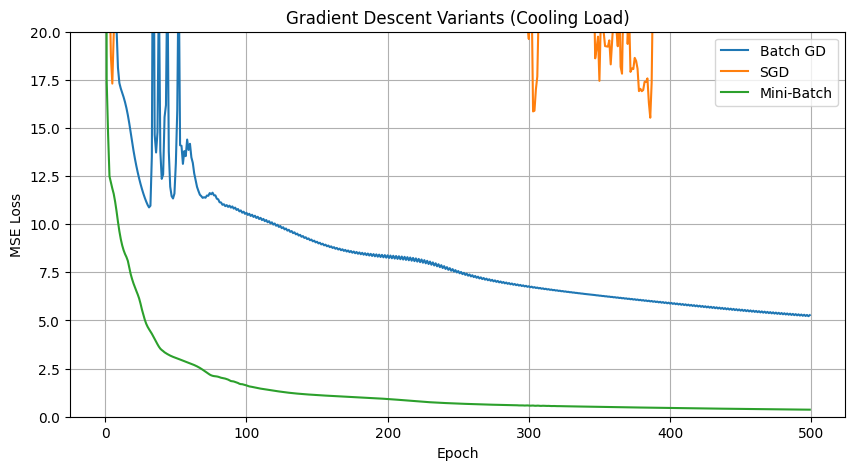

In [74]:
# ============================================================
# PHASE 3: Gradient Descent Variants (Cooling Load)
# ============================================================

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

def build_best_model():
    model = keras.Sequential([
        keras.Input(shape=(8,)),
        layers.Dense(16, activation='sigmoid'),
        layers.Dense(8, activation='sigmoid'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.1),
        loss='mse'
    )
    return model


gd_results = {}
gd_histories = {}

print(f"{'Variant':<15} {'Batch Size':<15} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>8}")
print("=" * 70)

# --- Batch GD ---
model = build_best_model()
history = model.fit(X_train_scaled, y_train,
                    epochs=500,
                    batch_size=len(X_train_scaled),
                    verbose=0)

train_loss = history.history['loss'][-1]
test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

gd_results['Batch GD'] = (train_loss, test_loss)
gd_histories['Batch GD'] = history.history['loss']

print(f"{'Batch GD':<15} {len(X_train_scaled):<15} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")


# --- SGD ---
model = build_best_model()
history = model.fit(X_train_scaled, y_train,
                    epochs=500,
                    batch_size=1,
                    verbose=0)

train_loss = history.history['loss'][-1]
test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

gd_results['SGD'] = (train_loss, test_loss)
gd_histories['SGD'] = history.history['loss']

print(f"{'SGD':<15} {'1':<15} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")


# --- Mini-Batch ---
model = build_best_model()
history = model.fit(X_train_scaled, y_train,
                    epochs=500,
                    batch_size=32,
                    verbose=0)

train_loss = history.history['loss'][-1]
test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

gd_results['Mini-Batch'] = (train_loss, test_loss)
gd_histories['Mini-Batch'] = history.history['loss']

print(f"{'Mini-Batch':<15} {'32':<15} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")


# --- Best Variant ---
best_gd = min(gd_results, key=lambda x: gd_results[x][1])

print(f"\n Best Variant for Cooling Load: {best_gd}")
print(f" Train Loss: {gd_results[best_gd][0]:.4f} | Test Loss: {gd_results[best_gd][1]:.4f}")


# --- Plot ---
plt.figure(figsize=(10, 5))

for name, loss in gd_histories.items():
    plt.plot(loss, label=name)

plt.title("Gradient Descent Variants (Cooling Load)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.ylim(0, 20)
plt.legend()
plt.grid(True)

plt.show()

Optimizer                   Train Loss    Test Loss     Diff
Batch+Time                      6.2620       6.1126   0.1494
Batch+Step                      8.7888       8.7985   0.0097
Batch+Exp                       8.3184       8.5748   0.2563
SGD+Time                        3.1545       2.9957   0.1588
SGD+Step                       17.7733      19.0045   1.2312
SGD+Exp                        16.7481      18.0730   1.3248
Mini-Batch+Time                 2.3204       2.2158   0.1046
Mini-Batch+Step                 9.9645       9.6158   0.3487
Mini-Batch+Exp                  9.5224       9.3012   0.2212

 Best for Cooling Load: Mini-Batch+Time
 Train Loss: 2.3204 | Test Loss: 2.2158


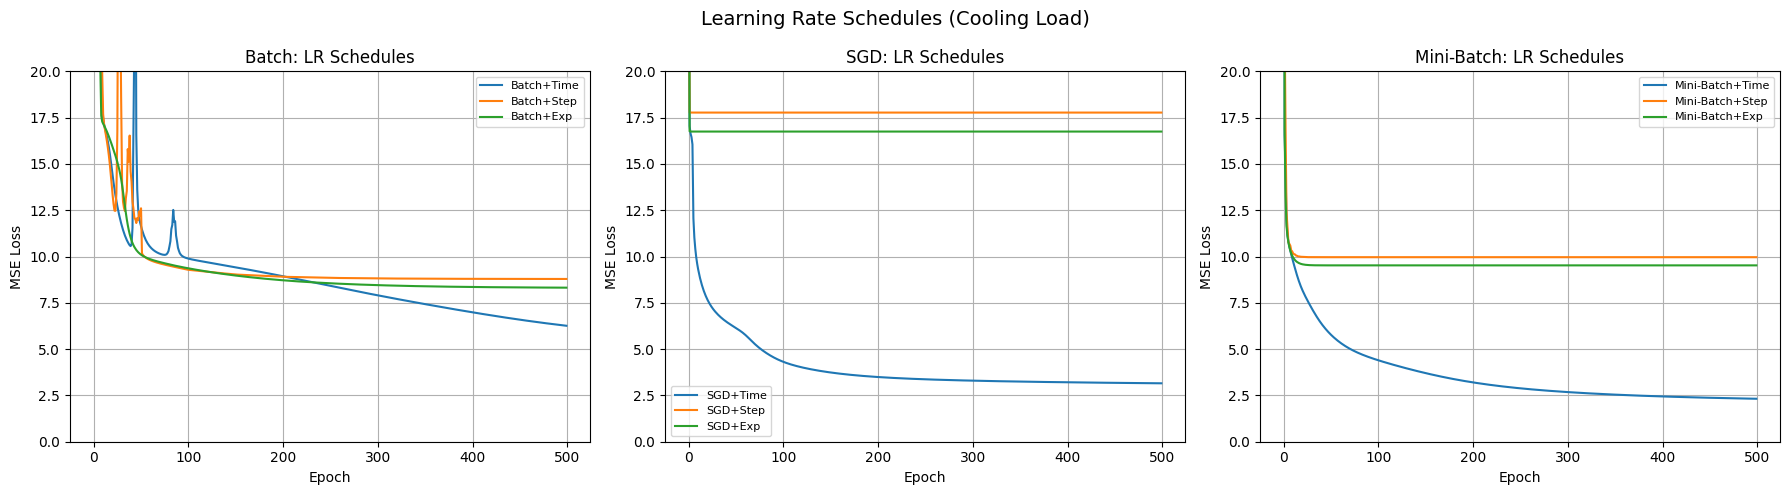

In [75]:
# ============================================================
# PHASE 4: Learning Rate Schedules (Cooling Load)
# ============================================================

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

def build_model(lr_schedule):
    model = keras.Sequential([
        keras.Input(shape=(8,)),
        layers.Dense(16, activation='sigmoid'),
        layers.Dense(8, activation='sigmoid'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=lr_schedule),
        loss='mse'
    )
    return model


schedule_results = {}
schedule_histories = {}

variants = {
    'Batch'     : len(X_train_scaled),
    'SGD'       : 1,
    'Mini-Batch': 32
}

print(f"{'Optimizer':<25} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>8}")
print("=" * 65)

for variant_name, batch_size in variants.items():

    # --- Time Decay ---
    lr_time = keras.optimizers.schedules.InverseTimeDecay(
        initial_learning_rate=0.1,
        decay_steps=1,
        decay_rate=0.01
    )
    model = build_model(lr_time)

    history = model.fit(X_train_scaled, y_train,
                        epochs=500, batch_size=batch_size, verbose=0)

    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

    key = f"{variant_name}+Time"
    schedule_results[key] = (train_loss, test_loss)
    schedule_histories[key] = history.history['loss']

    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")


    # --- Step Decay (staircase exponential) ---
    lr_step = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.1,
        decay_steps=50,
        decay_rate=0.5,
        staircase=True
    )
    model = build_model(lr_step)

    history = model.fit(X_train_scaled, y_train,
                        epochs=500, batch_size=batch_size, verbose=0)

    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

    key = f"{variant_name}+Step"
    schedule_results[key] = (train_loss, test_loss)
    schedule_histories[key] = history.history['loss']

    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")


    # --- Exponential Decay ---
    lr_exp = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.1,
        decay_steps=1,
        decay_rate=0.99,
        staircase=False
    )
    model = build_model(lr_exp)

    history = model.fit(X_train_scaled, y_train,
                        epochs=500, batch_size=batch_size, verbose=0)

    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

    key = f"{variant_name}+Exp"
    schedule_results[key] = (train_loss, test_loss)
    schedule_histories[key] = history.history['loss']

    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")


# --- Best ---
best = min(schedule_results, key=lambda x: schedule_results[x][1])

print(f"\n Best for Cooling Load: {best}")
print(f" Train Loss: {schedule_results[best][0]:.4f} | Test Loss: {schedule_results[best][1]:.4f}")


# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
variant_names = ['Batch', 'SGD', 'Mini-Batch']

for idx, variant_name in enumerate(variant_names):
    for key, loss in schedule_histories.items():
        if key.startswith(variant_name):
            axes[idx].plot(loss, label=key)

    axes[idx].set_title(f"{variant_name}: LR Schedules")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")
    axes[idx].set_ylim(0, 20)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.suptitle("Learning Rate Schedules (Cooling Load)", fontsize=14)
plt.tight_layout()
plt.show()

Optimizer                   Train Loss    Test Loss     Diff
Batch+Momentum                 92.1680      83.6667   8.5013
Batch+Nesterov                 17.6246      18.9171   1.2925
SGD+Momentum                 1629.4906     559.5789 1069.9117
SGD+Nesterov                  491.1425      81.7600 409.3825
Mini-Batch+Momentum            98.5736      95.4441   3.1295
Mini-Batch+Nesterov           120.6367     109.4415  11.1952

 Best for Cooling Load: Batch+Nesterov
 Train Loss: 17.6246 | Test Loss: 18.9171


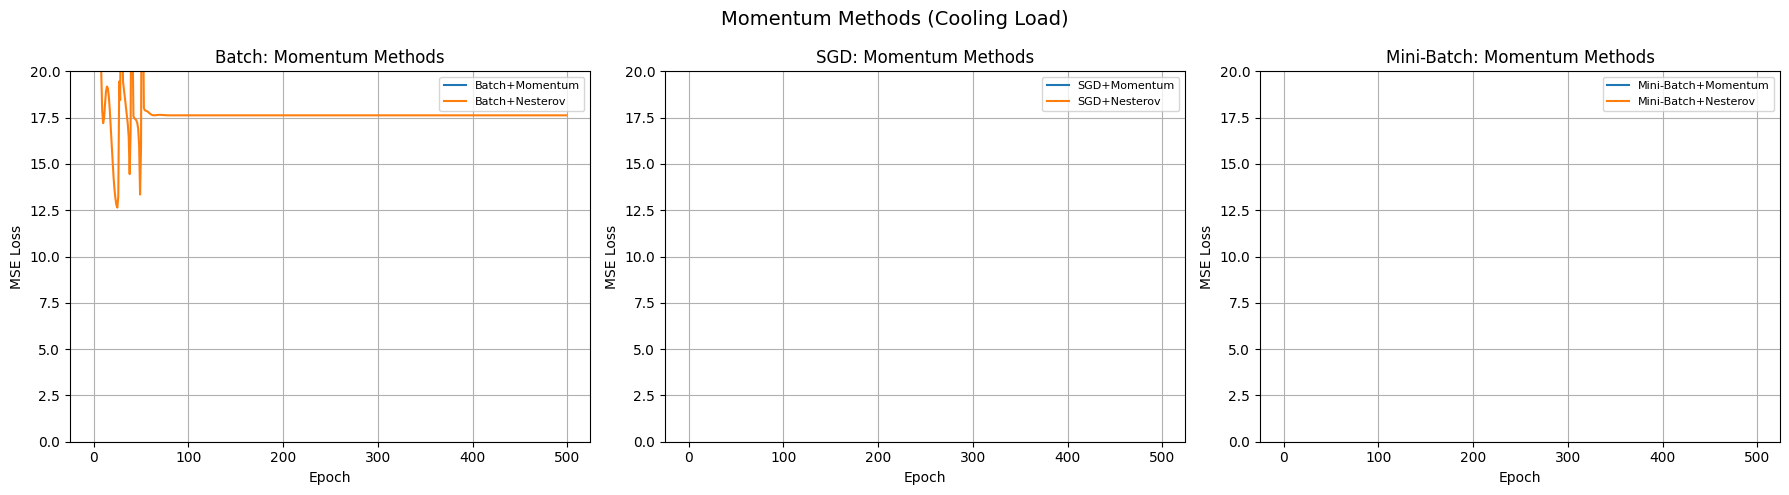

In [76]:
# ============================================================
# PHASE 5: Momentum Methods (Cooling Load)
# ============================================================

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

def build_model(momentum=0.0, nesterov=False):
    model = keras.Sequential([
        keras.Input(shape=(8,)),
        layers.Dense(16, activation='sigmoid'),
        layers.Dense(8, activation='sigmoid'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=0.1,
            momentum=momentum,
            nesterov=nesterov
        ),
        loss='mse'
    )
    return model


momentum_results = {}
momentum_histories = {}

variants = {
    'Batch'     : len(X_train_scaled),
    'SGD'       : 1,
    'Mini-Batch': 32
}

print(f"{'Optimizer':<25} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>8}")
print("=" * 65)

for variant_name, batch_size in variants.items():

    # --- Classical Momentum ---
    model = build_model(momentum=0.9, nesterov=False)

    history = model.fit(
        X_train_scaled, y_train,
        epochs=500,
        batch_size=batch_size,
        verbose=0
    )

    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

    key = f"{variant_name}+Momentum"
    momentum_results[key] = (train_loss, test_loss)
    momentum_histories[key] = history.history['loss']

    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")


    # --- Nesterov ---
    model = build_model(momentum=0.9, nesterov=True)

    history = model.fit(
        X_train_scaled, y_train,
        epochs=500,
        batch_size=batch_size,
        verbose=0
    )

    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

    key = f"{variant_name}+Nesterov"
    momentum_results[key] = (train_loss, test_loss)
    momentum_histories[key] = history.history['loss']

    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")


# --- Best ---
best = min(momentum_results, key=lambda x: momentum_results[x][1])

print(f"\n Best for Cooling Load: {best}")
print(f" Train Loss: {momentum_results[best][0]:.4f} | Test Loss: {momentum_results[best][1]:.4f}")


# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
variant_names = ['Batch', 'SGD', 'Mini-Batch']

for idx, variant_name in enumerate(variant_names):
    for key, loss in momentum_histories.items():
        if key.startswith(variant_name):
            axes[idx].plot(loss, label=key)

    axes[idx].set_title(f"{variant_name}: Momentum Methods")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")
    axes[idx].set_ylim(0, 20)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.suptitle("Momentum Methods (Cooling Load)", fontsize=14)
plt.tight_layout()
plt.show()

Optimizer                   Train Loss    Test Loss     Diff
Batch+Momentum                  3.7994       3.5185   0.2809
Batch+Nesterov                  5.1836       5.9289   0.7452
SGD+Momentum                   24.9272      17.8433   7.0839
SGD+Nesterov                   20.3788      16.8936   3.4852
Mini-Batch+Momentum             0.6770       1.0193   0.3423
Mini-Batch+Nesterov             0.3144       0.7674   0.4530

 Best Optimizer for Cooling Load: Mini-Batch+Nesterov
 Train Loss: 0.3144 | Test Loss: 0.7674


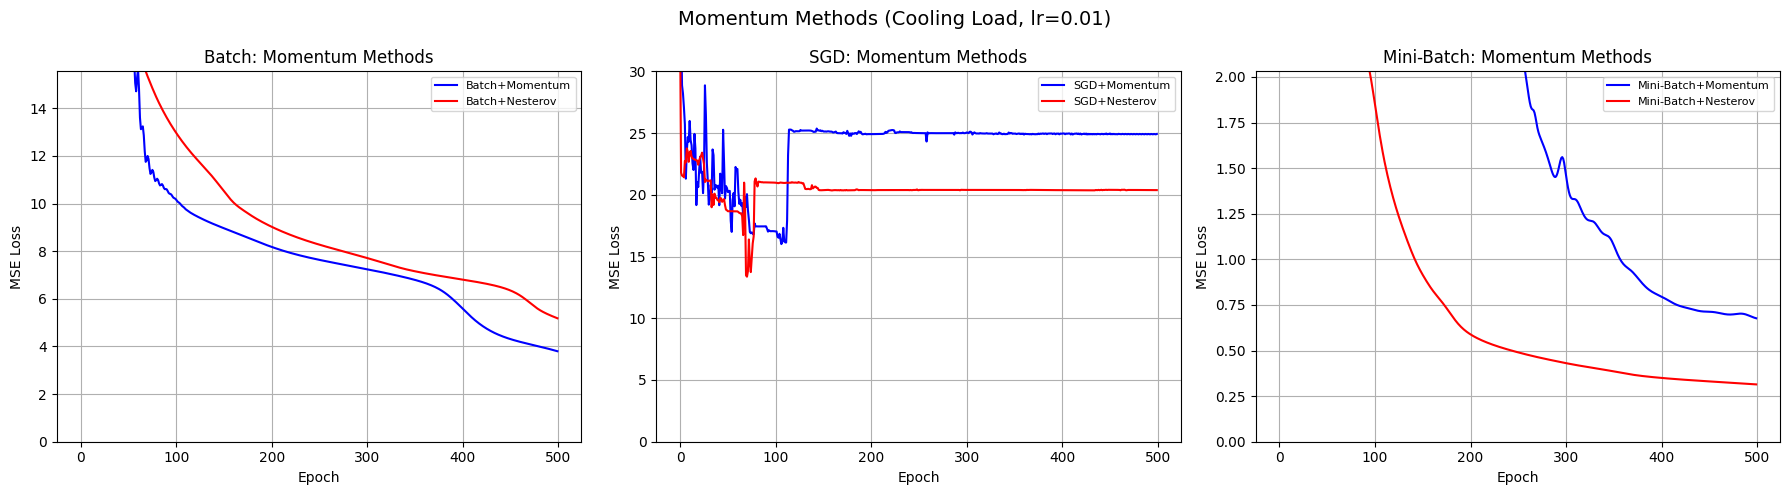

In [77]:
# ============================================================
# PHASE 5: Momentum Methods (Cooling Load)
# Architecture: 8→16→8→1, sigmoid, lr=0.01, 500 epochs
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import random
import matplotlib.pyplot as plt

# --- Seeds ---
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

momentum_results = {}
momentum_histories = {}

variants = {
    'Batch'     : len(X_train_scaled),
    'SGD'       : 1,
    'Mini-Batch': 32
}

print(f"{'Optimizer':<25} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>8}")
print("=" * 65)

for variant_name, batch_size in variants.items():

    # --- Classical Momentum ---
    model = keras.Sequential([
        keras.Input(shape=(8,)),
        layers.Dense(16, activation='sigmoid'),
        layers.Dense(8, activation='sigmoid'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=0.01,
            momentum=0.9
        ),
        loss='mse'
    )

    history = model.fit(
        X_train_scaled, y_train,
        epochs=500,
        batch_size=batch_size,
        shuffle=True,
        verbose=0
    )

    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

    key = f"{variant_name}+Momentum"
    momentum_results[key] = (train_loss, test_loss)
    momentum_histories[key] = history.history['loss']

    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")


    # --- Nesterov Momentum ---
    model = keras.Sequential([
        keras.Input(shape=(8,)),
        layers.Dense(16, activation='sigmoid'),
        layers.Dense(8, activation='sigmoid'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=0.01,
            momentum=0.9,
            nesterov=True
        ),
        loss='mse'
    )

    history = model.fit(
        X_train_scaled, y_train,
        epochs=500,
        batch_size=batch_size,
        shuffle=True,
        verbose=0
    )

    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

    key = f"{variant_name}+Nesterov"
    momentum_results[key] = (train_loss, test_loss)
    momentum_histories[key] = history.history['loss']

    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")


# --- Find Best Optimizer ---
best = min(momentum_results, key=lambda x: momentum_results[x][1])

print(f"\n Best Optimizer for Cooling Load: {best}")
print(f" Train Loss: {momentum_results[best][0]:.4f} | Test Loss: {momentum_results[best][1]:.4f}")


# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
variant_names = ['Batch', 'SGD', 'Mini-Batch']
colors = ['blue', 'red']

for idx, variant_name in enumerate(variant_names):

    keys = [k for k in momentum_histories if k.startswith(variant_name)]

    for i, key in enumerate(keys):
        axes[idx].plot(momentum_histories[key], label=key, color=colors[i])

    axes[idx].set_title(f"{variant_name}: Momentum Methods")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")

    # Dynamic Y-axis scaling
    final_losses = [momentum_histories[k][-1] for k in keys]
    axes[idx].set_ylim(0, min(max(final_losses) * 3, 30))

    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.suptitle("Momentum Methods (Cooling Load, lr=0.01)", fontsize=14)
plt.tight_layout()
plt.show()

Optimizer                   Train Loss    Test Loss     Diff
Batch+AdaGrad                 545.5711     477.8419  67.7292
Batch+RMSProp                 427.0316     367.5248  59.5068
Batch+Adam                    453.4225     391.8186  61.6039
Batch+Adamax                  544.3949     476.4433  67.9516
Batch+Adadelta                772.8165     691.5182  81.2983
SGD+AdaGrad                    18.1573      17.3793   0.7781
SGD+RMSProp                     2.0706       2.3829   0.3123
SGD+Adam                        2.1576       2.5867   0.4291
SGD+Adamax                      2.7282       2.5846   0.1436
SGD+Adadelta                  549.4752     481.2495  68.2256
Mini-Batch+AdaGrad            178.9228     144.3541  34.5687
Mini-Batch+RMSProp              8.4772       8.6257   0.1485
Mini-Batch+Adam                16.1822      17.7423   1.5601
Mini-Batch+Adamax               8.6671       8.6187   0.0484
Mini-Batch+Adadelta           655.4315     580.7595  74.6719

 Best Optimizer for Coo

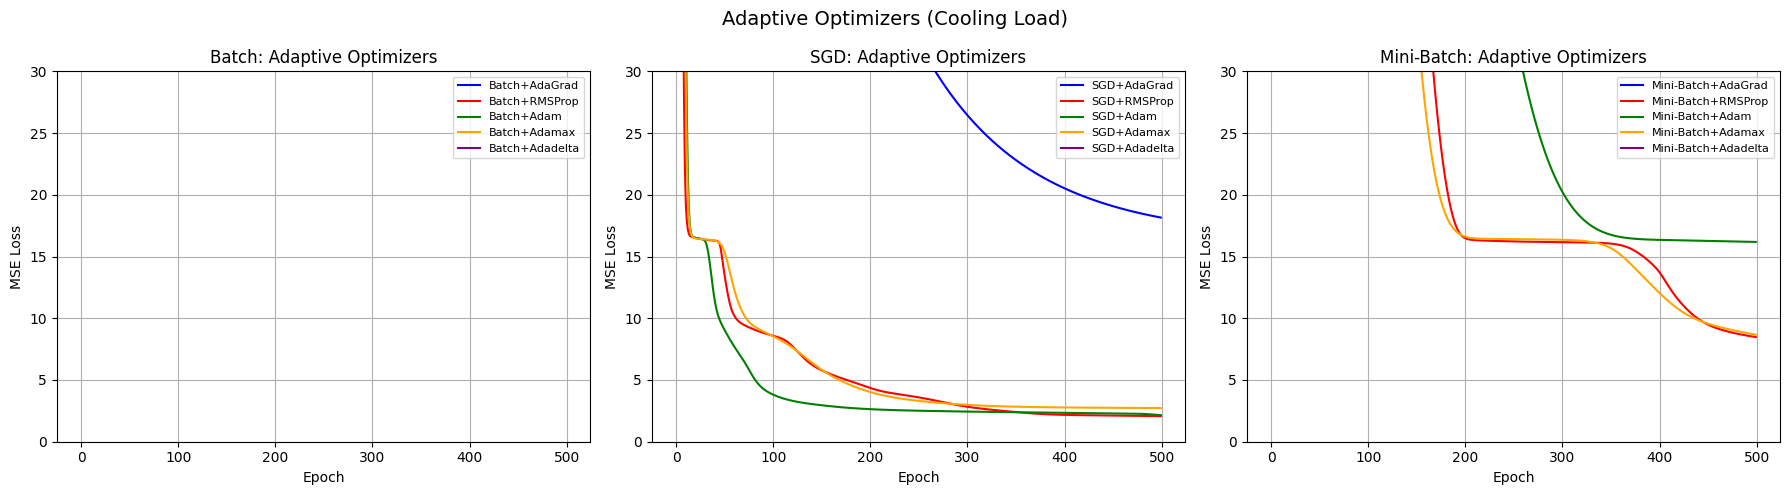

In [78]:
# ============================================================
# PHASE 6: Adaptive Optimizers (Cooling Load)
# Architecture: 8→16→8→1, sigmoid, 500 epochs
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import random
import matplotlib.pyplot as plt

# --- Seeds ---
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

adaptive_results = {}
adaptive_histories = {}

variants = {
    'Batch'     : len(X_train_scaled),
    'SGD'       : 1,
    'Mini-Batch': 32
}

optimizers_dict = {
    'AdaGrad'  : lambda: keras.optimizers.Adagrad(learning_rate=0.01),
    'RMSProp'  : lambda: keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam'     : lambda: keras.optimizers.Adam(learning_rate=0.001),
    'Adamax'   : lambda: keras.optimizers.Adamax(learning_rate=0.002),
    'Adadelta' : lambda: keras.optimizers.Adadelta(learning_rate=0.001),
}

print(f"{'Optimizer':<25} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>8}")
print("=" * 65)

for variant_name, batch_size in variants.items():
    for opt_name, opt_fn in optimizers_dict.items():

        model = keras.Sequential([
            keras.Input(shape=(8,)),
            layers.Dense(16, activation='sigmoid'),
            layers.Dense(8, activation='sigmoid'),
            layers.Dense(1)
        ])

        model.compile(optimizer=opt_fn(), loss='mse')

        history = model.fit(
            X_train_scaled, y_train,
            epochs=500,
            batch_size=batch_size,
            shuffle=True,   # important 🔥
            verbose=0
        )

        train_loss = history.history['loss'][-1]
        test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

        key = f"{variant_name}+{opt_name}"
        adaptive_results[key] = (train_loss, test_loss)
        adaptive_histories[key] = history.history['loss']

        print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")


# --- Best Optimizer ---
best = min(adaptive_results, key=lambda x: adaptive_results[x][1])

print(f"\n Best Optimizer for Cooling Load: {best}")
print(f" Train Loss: {adaptive_results[best][0]:.4f} | Test Loss: {adaptive_results[best][1]:.4f}")


# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
variant_names = ['Batch', 'SGD', 'Mini-Batch']
colors = ['blue', 'red', 'green', 'orange', 'purple']

for idx, variant_name in enumerate(variant_names):

    keys = [k for k in adaptive_histories if k.startswith(variant_name)]

    for i, key in enumerate(keys):
        axes[idx].plot(adaptive_histories[key], label=key, color=colors[i])

    axes[idx].set_title(f"{variant_name}: Adaptive Optimizers")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")

    final_losses = [adaptive_histories[k][-1] for k in keys]
    axes[idx].set_ylim(0, min(max(final_losses) * 3, 30))

    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.suptitle("Adaptive Optimizers (Cooling Load)", fontsize=14)
plt.tight_layout()
plt.show()

Optimizer                      Train Loss    Test Loss       Diff
Batch GD                           5.2766       5.1796     0.0970
SGD                               26.0485      16.1967     9.8518
Mini-Batch                         0.3665       0.8944     0.5279
Batch+Time                         6.2620       6.1126     0.1494
Batch+Step                         8.7888       8.7985     0.0097
Batch+Exp                          8.3184       8.5748     0.2563
SGD+Time                           3.1545       2.9957     0.1588
SGD+Step                          17.7733      19.0045     1.2312
SGD+Exp                           16.7481      18.0730     1.3248
Mini-Batch+Time                    2.3204       2.2158     0.1046
Mini-Batch+Step                    9.9645       9.6158     0.3487
Mini-Batch+Exp                     9.5224       9.3012     0.2212
Batch+Momentum                     3.7994       3.5185     0.2809
Batch+Nesterov                     5.1836       5.9289     0.7452
SGD+Moment

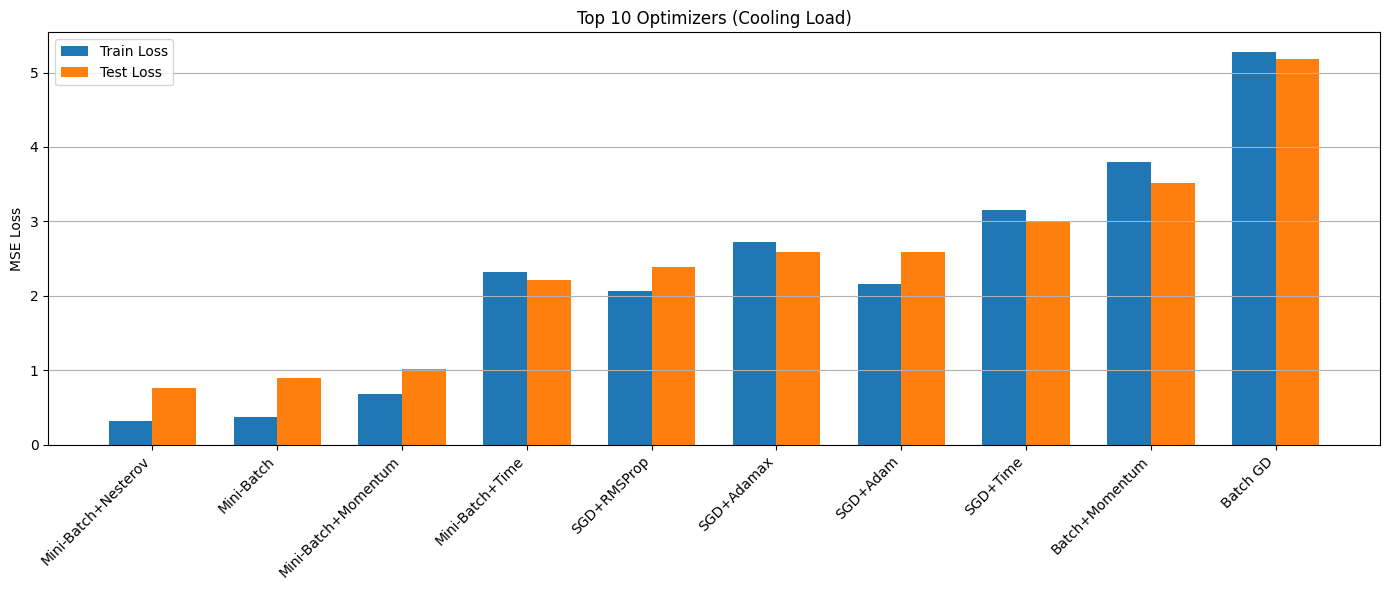

In [79]:
# ============================================================
# PHASE 7: Final Comparison Table — All Optimizers (Cooling Load)
# ============================================================

all_results = {}

# --- Phase 3 ---
all_results['Batch GD']   = gd_results['Batch GD']
all_results['SGD']        = gd_results['SGD']
all_results['Mini-Batch'] = gd_results['Mini-Batch']

# --- Phase 4 ---
all_results.update({
    'Batch+Time': schedule_results['Batch+Time'],
    'Batch+Step': schedule_results['Batch+Step'],
    'Batch+Exp' : schedule_results['Batch+Exp'],
    'SGD+Time'  : schedule_results['SGD+Time'],
    'SGD+Step'  : schedule_results['SGD+Step'],
    'SGD+Exp'   : schedule_results['SGD+Exp'],
    'Mini-Batch+Time': schedule_results['Mini-Batch+Time'],
    'Mini-Batch+Step': schedule_results['Mini-Batch+Step'],
    'Mini-Batch+Exp' : schedule_results['Mini-Batch+Exp'],
})

# --- Phase 5 ---
all_results.update({
    'Batch+Momentum': momentum_results['Batch+Momentum'],
    'Batch+Nesterov': momentum_results['Batch+Nesterov'],
    'SGD+Momentum'  : momentum_results['SGD+Momentum'],
    'SGD+Nesterov'  : momentum_results['SGD+Nesterov'],
    'Mini-Batch+Momentum': momentum_results['Mini-Batch+Momentum'],
    'Mini-Batch+Nesterov': momentum_results['Mini-Batch+Nesterov'],
})

# --- Phase 6 ---
all_results.update({
    'Batch+AdaGrad': adaptive_results['Batch+AdaGrad'],
    'Batch+RMSProp': adaptive_results['Batch+RMSProp'],
    'Batch+Adam'   : adaptive_results['Batch+Adam'],
    'Batch+Adamax' : adaptive_results['Batch+Adamax'],
    'Batch+Adadelta': adaptive_results['Batch+Adadelta'],

    'SGD+AdaGrad': adaptive_results['SGD+AdaGrad'],
    'SGD+RMSProp': adaptive_results['SGD+RMSProp'],
    'SGD+Adam'   : adaptive_results['SGD+Adam'],
    'SGD+Adamax' : adaptive_results['SGD+Adamax'],
    'SGD+Adadelta': adaptive_results['SGD+Adadelta'],

    'Mini-Batch+AdaGrad': adaptive_results['Mini-Batch+AdaGrad'],
    'Mini-Batch+RMSProp': adaptive_results['Mini-Batch+RMSProp'],
    'Mini-Batch+Adam'   : adaptive_results['Mini-Batch+Adam'],
    'Mini-Batch+Adamax' : adaptive_results['Mini-Batch+Adamax'],
    'Mini-Batch+Adadelta': adaptive_results['Mini-Batch+Adadelta'],
})

# --- Print Table ---
print(f"{'Optimizer':<28} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>10}")
print("=" * 70)

for name, (train, test) in all_results.items():
    diff = abs(test - train)
    print(f"{name:<28} {train:>12.4f} {test:>12.4f} {diff:>10.4f}")

# --- Best ---
best = min(all_results, key=lambda x: all_results[x][1])

print("\n" + "="*70)
print(f" Overall Best Optimizer (Cooling Load): {best}")
print(f" Train Loss: {all_results[best][0]:.4f}")
print(f" Test Loss : {all_results[best][1]:.4f}")
print(f" Difference: {abs(all_results[best][1]-all_results[best][0]):.4f}")

# --- Top 10 Plot ---
sorted_results = sorted(all_results.items(), key=lambda x: x[1][1])
top10 = sorted_results[:10]

names  = [x[0] for x in top10]
trains = [x[1][0] for x in top10]
tests  = [x[1][1] for x in top10]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14,6))
ax.bar(x - width/2, trains, width, label='Train Loss')
ax.bar(x + width/2, tests,  width, label='Test Loss')

ax.set_title("Top 10 Optimizers (Cooling Load)")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

Optimizer                  Manual Train   Manual Test   TF Train    TF Test    Improvement

--- GD Variants ---
Batch GD                         7.8834        7.2272     5.2766     5.1796    ✓ TF Better
SGD                              1.0972        1.2202    26.0485    16.1967 ✗ Manual Better
Mini-Batch                       1.4802        1.6511     0.3665     0.8944    ✓ TF Better

--- LR Schedules ---
Batch+Time                       8.4034        7.6832     6.2620     6.1126    ✓ TF Better
SGD+Time                         0.5267        0.5466     3.1545     2.9957 ✗ Manual Better
Mini-Batch+Time                  2.7006        3.0276     2.3204     2.2158    ✓ TF Better
Batch+Step                       9.7291        9.0116     8.7888     8.7985    ✓ TF Better
SGD+Step                         0.7303        0.7416    17.7733    19.0045 ✗ Manual Better
Mini-Batch+Step                  4.0470        4.1507     9.9645     9.6158 ✗ Manual Better
Batch+Exp                       12.0541    

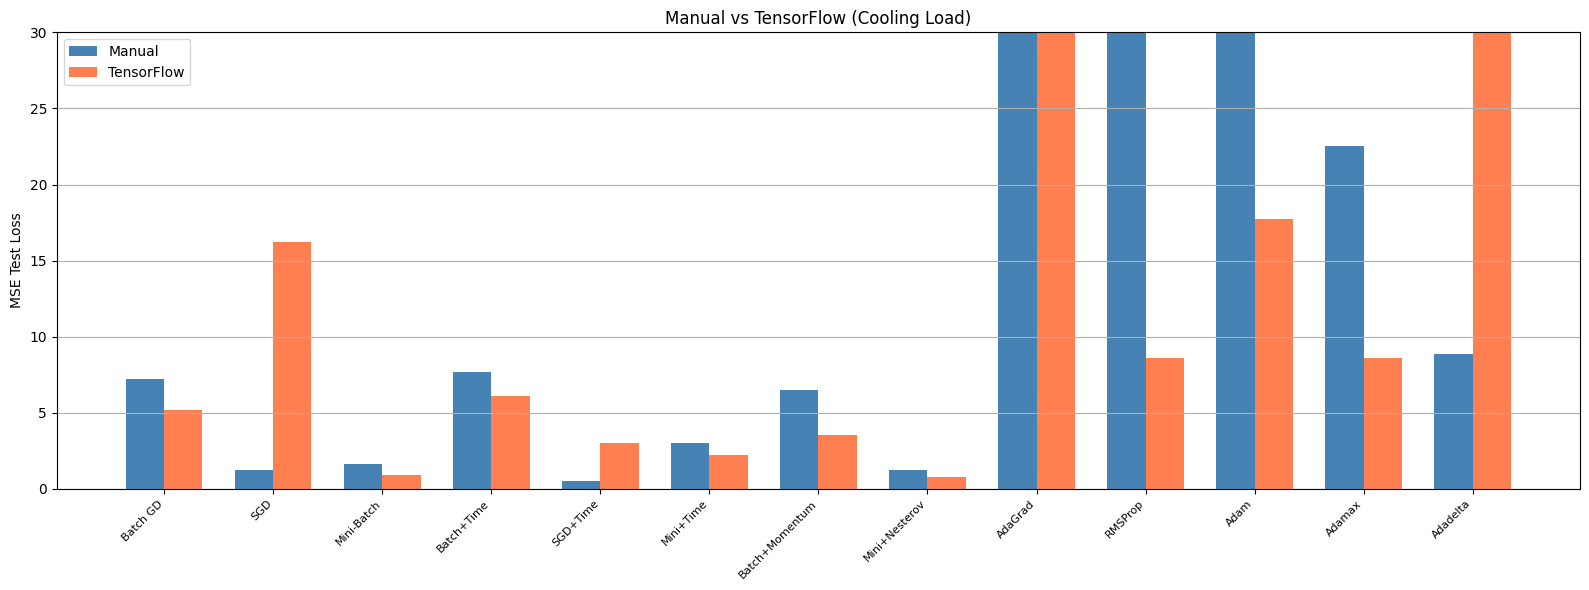

In [80]:
# ============================================================
# PHASE 8: Manual vs TensorFlow Comparison (Cooling Load)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

manual_results = {
    # --- GD Variants ---
    'Batch GD'             : (7.8834, 7.2272),
    'SGD'                  : (1.0972, 1.2202),
    'Mini-Batch'           : (1.4802, 1.6511),

    # --- LR Schedules ---
    'Batch+Time'           : (8.4034, 7.6832),
    'SGD+Time'             : (0.5267, 0.5466),
    'Mini-Batch+Time'      : (2.7006, 3.0276),
    'Batch+Step'           : (9.7291, 9.0116),
    'SGD+Step'             : (0.7303, 0.7416),
    'Mini-Batch+Step'      : (4.0470, 4.1507),
    'Batch+Exp'            : (12.0541, 11.3332),
    'SGD+Exp'              : (1.4438, 1.4583),
    'Mini-Batch+Exp'       : (6.1830, 6.0247),

    # --- Momentum ---
    'Batch+Momentum'       : (6.0896, 6.4897),
    'SGD+Momentum'         : (3.2384, 3.7466),
    'Mini-Batch+Momentum'  : (1.0280, 0.8750),
    'Batch+Nesterov'       : (5.6511, 6.0497),
    'SGD+Nesterov'         : (1.3354, 1.4800),
    'Mini-Batch+Nesterov'  : (1.3576, 1.2593),

    # --- Adaptive ---
    'AdaGrad'              : (318.9007, 260.4520),
    'RMSProp'              : (71.9875, 50.4876),
    'Adam'                 : (99.5545, 71.6622),
    'Adamax'               : (31.8184, 22.5604),
    'Adadelta'             : (9.1726, 8.8812),
}

print("=" * 95)
print(f"{'Optimizer':<25} {'Manual Train':>13} {'Manual Test':>13} {'TF Train':>10} {'TF Test':>10} {'Improvement':>14}")
print("=" * 95)

groups = {
    'GD Variants': [
        ('Batch GD', 'Batch GD'),
        ('SGD', 'SGD'),
        ('Mini-Batch', 'Mini-Batch'),
    ],
    'LR Schedules': [
        ('Batch+Time','Batch+Time'), ('SGD+Time','SGD+Time'), ('Mini-Batch+Time','Mini-Batch+Time'),
        ('Batch+Step','Batch+Step'), ('SGD+Step','SGD+Step'), ('Mini-Batch+Step','Mini-Batch+Step'),
        ('Batch+Exp','Batch+Exp'), ('SGD+Exp','SGD+Exp'), ('Mini-Batch+Exp','Mini-Batch+Exp'),
    ],
    'Momentum': [
        ('Batch+Momentum','Batch+Momentum'), ('SGD+Momentum','SGD+Momentum'),
        ('Mini-Batch+Momentum','Mini-Batch+Momentum'),
        ('Batch+Nesterov','Batch+Nesterov'), ('SGD+Nesterov','SGD+Nesterov'),
        ('Mini-Batch+Nesterov','Mini-Batch+Nesterov'),
    ],
    'Adaptive': [
        ('AdaGrad','Mini-Batch+AdaGrad'),
        ('RMSProp','Mini-Batch+RMSProp'),
        ('Adam','Mini-Batch+Adam'),
        ('Adamax','Mini-Batch+Adamax'),
        ('Adadelta','Mini-Batch+Adadelta'),
    ],
}

for group_name, pairs in groups.items():
    print(f"\n--- {group_name} ---")
    for manual_key, tf_key in pairs:
        m_train, m_test = manual_results[manual_key]
        tf_train, tf_test = all_results[tf_key]

        improvement = m_test - tf_test
        direction = '✓ TF Better' if improvement > 0 else '✗ Manual Better'

        print(f"{manual_key:<25} {m_train:>13.4f} {m_test:>13.4f} "
              f"{tf_train:>10.4f} {tf_test:>10.4f} {direction:>14}")

# --- Best Comparison ---
best_manual = min(manual_results, key=lambda x: manual_results[x][1])
best_tf = min(all_results, key=lambda x: all_results[x][1])

print("\n" + "="*95)
print(f" Best Manual Optimizer  : {best_manual:<25} Test Loss: {manual_results[best_manual][1]:.4f}")
print(f" Best TF Optimizer      : {best_tf:<25} Test Loss: {all_results[best_tf][1]:.4f}")
print(f" Overall Improvement    : {manual_results[best_manual][1] - all_results[best_tf][1]:.4f}")

# --- Plot ---
labels = ['Batch GD','SGD','Mini-Batch','Batch+Time','SGD+Time','Mini+Time',
          'Batch+Momentum','Mini+Nesterov','AdaGrad','RMSProp','Adam','Adamax','Adadelta']

manual_tests = [7.2272,1.2202,1.6511,7.6832,0.5466,3.0276,
                6.4897,1.2593,260.452,50.4876,71.6622,22.5604,8.8812]

tf_tests = [
    all_results['Batch GD'][1],
    all_results['SGD'][1],
    all_results['Mini-Batch'][1],
    all_results['Batch+Time'][1],
    all_results['SGD+Time'][1],
    all_results['Mini-Batch+Time'][1],
    all_results['Batch+Momentum'][1],
    all_results['Mini-Batch+Nesterov'][1],
    all_results['Mini-Batch+AdaGrad'][1],
    all_results['Mini-Batch+RMSProp'][1],
    all_results['Mini-Batch+Adam'][1],
    all_results['Mini-Batch+Adamax'][1],
    all_results['Mini-Batch+Adadelta'][1],
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(16,6))
ax.bar(x - width/2, manual_tests, width, label='Manual', color='steelblue')
ax.bar(x + width/2, tf_tests, width, label='TensorFlow', color='coral')

ax.set_title("Manual vs TensorFlow (Cooling Load)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("MSE Test Loss")
ax.set_ylim(0, 30)
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

Training Top Models (Cooling Load)...

Model                       MSE     RMSE      MAE       R²
Mini-Batch               0.8918   0.9444   0.6278   0.9891
Mini-Batch+Nesterov      2.5904   1.6095   1.0893   0.9683


SGD+Adam                 1.2225   1.1057   0.7957   0.9850


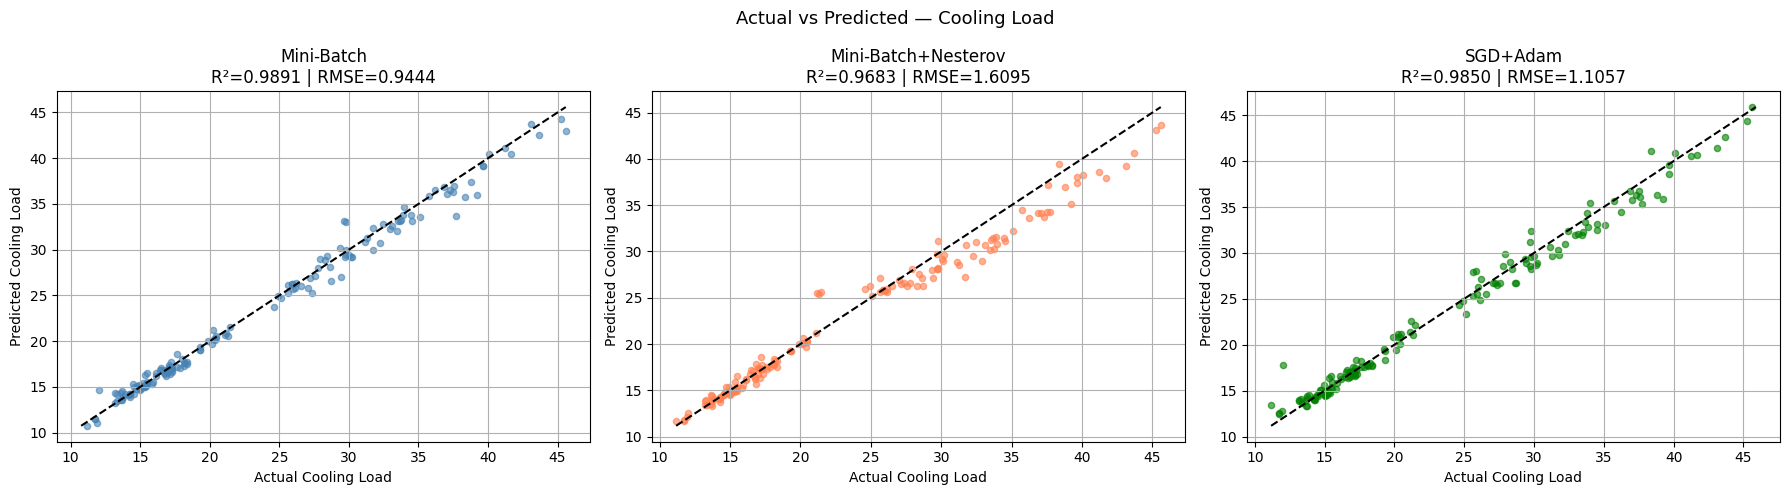

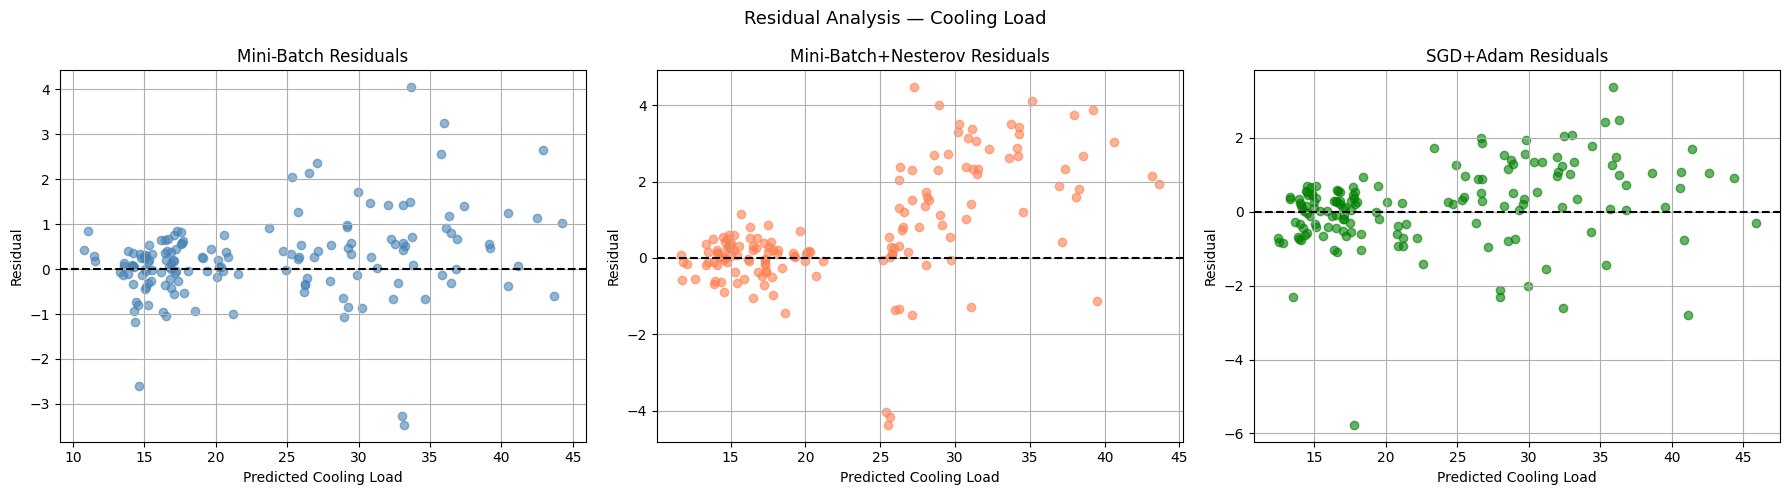


COOLING LOAD PREDICTION SYSTEM
Relative Compactness: 0
Surface Area: 0
Wall Area: 0
Roof Area: 0
Overall Height: 0
Orientation: 0
Glazing Area: 0
Glazing Area Distribution: 0

Predicted Cooling Load:

Mini-Batch            : 20.656 kWh/m²
Mini-Batch+Nesterov   : 11.053 kWh/m²
SGD+Adam              : 19.263 kWh/m²


In [81]:
# ============================================================
# FINAL PHASE: Professional Regression System (Cooling Load)
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# --- Training stats ---
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0)

# --- Model builder ---
def build_and_train(optimizer, batch_size, epochs=500):
    tf.random.set_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(8,)),
        layers.Dense(16, activation='sigmoid'),
        layers.Dense(8, activation='sigmoid'),
        layers.Dense(1)
    ])
    model.compile(optimizer=optimizer, loss='mse')
    model.fit(X_train_scaled, y_train,
              epochs=epochs, batch_size=batch_size,
              shuffle=True, verbose=0)
    return model

# --- Train Top Models ---
print("Training Top Models (Cooling Load)...\n")

model_mb = build_and_train(
    keras.optimizers.SGD(learning_rate=0.1),
    batch_size=32
)

model_nesterov = build_and_train(
    keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    batch_size=32
)

model_adam = build_and_train(
    keras.optimizers.Adam(learning_rate=0.001),
    batch_size=1
)

models = {
    'Mini-Batch'          : model_mb,
    'Mini-Batch+Nesterov' : model_nesterov,
    'SGD+Adam'            : model_adam,
}

# --- Evaluation ---
print("=" * 75)
print(f"{'Model':<22} {'MSE':>8} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("=" * 75)

trained_models = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled, verbose=0)

    mse  = float(np.mean((y_test - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))

    trained_models[name] = (model, y_pred, mse, rmse, mae, r2)

    print(f"{name:<22} {mse:>8.4f} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")

# --- Actual vs Predicted ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['steelblue', 'coral', 'green']
model_names = list(models.keys())
preds = [trained_models[name][1] for name in model_names]

for idx, (name, pred, color) in enumerate(zip(model_names, preds, colors)):
    axes[idx].scatter(y_test, pred, alpha=0.6, color=color, s=20)

    min_val = float(min(y_test.min(), pred.min()))
    max_val = float(max(y_test.max(), pred.max()))

    axes[idx].plot([min_val, max_val], [min_val, max_val], 'k--')

    r2   = trained_models[name][5]
    rmse = trained_models[name][3]

    axes[idx].set_title(f"{name}\nR²={r2:.4f} | RMSE={rmse:.4f}")
    axes[idx].set_xlabel("Actual Cooling Load")
    axes[idx].set_ylabel("Predicted Cooling Load")
    axes[idx].grid(True)

plt.suptitle("Actual vs Predicted — Cooling Load", fontsize=13)
plt.tight_layout()
plt.show()

# --- Residual Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, pred, color) in enumerate(zip(model_names, preds, colors)):
    residuals = y_test.flatten() - pred.flatten()

    axes[idx].scatter(pred.flatten(), residuals, alpha=0.6, color=color)
    axes[idx].axhline(y=0, color='black', linestyle='--')

    axes[idx].set_title(f"{name} Residuals")
    axes[idx].set_xlabel("Predicted Cooling Load")
    axes[idx].set_ylabel("Residual")
    axes[idx].grid(True)

plt.suptitle("Residual Analysis — Cooling Load", fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# INTERACTIVE PREDICTION
# ============================================================

print("\n" + "=" * 60)
print("COOLING LOAD PREDICTION SYSTEM")
print("=" * 60)

feature_names = [
    "Relative Compactness",
    "Surface Area",
    "Wall Area",
    "Roof Area",
    "Overall Height",
    "Orientation",
    "Glazing Area",
    "Glazing Area Distribution"
]

user_input = []
for fname in feature_names:
    val = float(input(f"{fname}: "))
    user_input.append(val)

user_array = np.array(user_input).reshape(1, -1)
user_scaled = (user_array - train_mean) / train_std

print("\nPredicted Cooling Load:\n")

for name, model in models.items():
    pred_val = float(model.predict(user_scaled, verbose=0)[0][0])
    print(f"{name:<22}: {pred_val:.3f} kWh/m²")